# 📊 PROJET CRISP-DM : Analyse et Prédiction des Temps de Livraison

---

## 🎯 PHASE 1 : BUSINESS UNDERSTANDING (Compréhension Métier)

### Contexte du Projet
Analyse du dataset `datadelevry.xlsx` pour optimiser les opérations logistiques d'un service de livraison.

### Objectifs Métiers (Business Objectives)

**BO1 : Réduction de dimensionnalité**
- Simplifier les données en résumant les informations clés
- Réduire le nombre de variables sans perte significative d'information
- Faciliter les analyses futures et améliorer les performances des modèles
- Identifier les composantes principales qui expliquent le mieux la variance des données

**BO2 : Prédire le temps de livraison**
- Estimer précisément combien de temps prendra chaque livraison
- Fournir un horaire fiable aux clients
- Réduire les frustrations et améliorer la satisfaction globale
- Optimiser la planification des ressources logistiques

**BO3 : Segmentation des commandes (Clustering)**
- Regrouper les commandes en groupes similaires
- Mieux organiser et assigner les livreurs
- Améliorer l'efficacité logistique
- Identifier des profils de commandes distincts

### Traduction en Objectifs Data Science

**Pour BO1 : Réduction de Dimensionnalité**
- Features numériques : `subtotal`, `min_item_price`, `max_item_price`, `total_items`, `num_distinct_items`, etc.
- Objectif : Conserver 85-95% de variance avec un nombre optimal de composantes
- Algorithmes : PCA (Principal Component Analysis), t-SNE pour visualisation
- Méthode de sélection : Test de k composantes dans l'intervalle [1, 11] avec analyse de la variance expliquée
- Prétraitement : Normalisation StandardScaler, imputation des valeurs manquantes

**Pour BO2 : Régression Supervisée**
- Variable cible : temps de livraison (différence en minutes entre `actual_delivery_time` et `created_at`)
- Features : `market_id`, `store_primary_category`, `total_items`, `subtotal`, `total_onshift_partners`, features météorologiques
- Modèles : Régression linéaire, Random Forest, Gradient Boosting, XGBoost, LightGBM
- Métriques : MAE, RMSE, R², MAPE

**Pour BO3 : Clustering Non Supervisé**
- Features : `market_id`, `total_items`, `subtotal`, `delivery_duration_min`, variables temporelles et météorologiques
- Algorithmes : K-means, DBSCAN
- Méthode de sélection : Test de k clusters dans l'intervalle [2, 11] avec Elbow method et Silhouette score
- Validation : Silhouette score, Calinski-Harabasz score, Davies-Bouldin index

---

## 📁 PHASE 2 : DATA UNDERSTANDING (Compréhension des Données)

### Objectif
Explorer et comprendre le dataset pour identifier les patterns, anomalies et relations entre les variables.

### Étapes
1. **Chargement des données** : Import du fichier Excel
2. **Exploration initiale** : Structure, dimensions, types de données
3. **Analyse descriptive** : Statistiques, distributions, corrélations
4. **Visualisations** : Graphiques pour comprendre les patterns
5. **Détection d'anomalies** : Outliers, valeurs manquantes

---


##  Chargement des librairies et définition du chemin du fichier
Cette cellule importe les librairies nécessaires (pandas, numpy, matplotlib, etc.) et définit le chemin du fichier de données à analyser.


In [5]:

# 1) Setup - imports et chemin du fichier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

# Chemin du fichier Excel - modifie si nécessaire
FILE_PATH = 'datadelevry.xlsx'
print('FILE_PATH =', FILE_PATH)
print('Working dir:', os.getcwd())


FILE_PATH = datadelevry.xlsx
Working dir: C:\Users\chams\OneDrive\Bureau\projetPIDEV\CRISP-DM-DataSet-Temps-de-livraison


## Lecture du fichier Excel
Cette cellule lit le fichier Excel, gère le cas où toutes les données sont dans une seule colonne, détecte et applique l’en-tête si besoin, puis affiche les premières lignes du jeu de données.


In [8]:

# 2) Lecture du fichier Excel
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Fichier non trouvé: {FILE_PATH}")

# Lire sans header pour gérer le cas "tout dans une seule colonne"
df_raw = pd.read_excel(FILE_PATH, header=None)
print('Raw shape:', df_raw.shape)

if df_raw.shape[1] == 1:
    print('Fichier avec une seule colonne détecté -> split par virgule')
    df = df_raw[0].astype(str).str.split(',', expand=True)
    # Détecter si la première ligne contient les noms de colonnes
    first_row = df.iloc[0].astype(str).str.lower().tolist()
    if any('created' in s or 'actual' in s or 'store' in s for s in first_row):
        df.columns = df.iloc[0]
        df = df[1:].reset_index(drop=True)
        print('En-tête détectée et appliquée. Nouvelle forme :', df.shape)
    else:
        df.columns = [f'col_{i}' for i in range(df.shape[1])]
        print('Aucun en-tête détecté ; colonnes génériques appliquées. Nouvelle forme :', df.shape)
else:
    df = df_raw.copy()
    # S'assurer que les noms de colonnes sont des strings propres
    df.columns = [str(c).strip() for c in df.columns]
    print('Fichier multi-colonnes chargé. Shape:', df.shape)

display(df.head(8))



Raw shape: (172942, 1)
Fichier avec une seule colonne détecté -> split par virgule
En-tête détectée et appliquée. Nouvelle forme : (172941, 14)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,,1.0,3.0,3900.0,3.0,,1600.0,6.0,6.0,9.0
5,3.0,2015-01-28 20:30:38,2015-01-28 21:08:58,f0ade77b43923b38237db569b016ba25,,1.0,3.0,5000.0,3.0,1500.0,1900.0,2.0,2.0,2.0
6,3.0,2015-01-31 02:16:36,2015-01-31 02:43:00,f0ade77b43923b38237db569b016ba25,,1.0,2.0,3900.0,2.0,1200.0,2700.0,10.0,9.0,9.0
7,3.0,2015-02-12 03:03:35,2015-02-12 03:36:20,f0ade77b43923b38237db569b016ba25,,1.0,4.0,4850.0,4.0,750.0,1800.0,7.0,8.0,7.0


##  Affichage des noms de colonnes
Cette cellule affiche la liste des colonnes et la résumé des manquants et détection simple d'outliers.


In [10]:
print('Colonnes  :')
print(df.columns.tolist())
display(df.head(5))
#  Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))


Colonnes  :
['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders']


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,,1.0,3.0,3900.0,3.0,,1600.0,6.0,6.0,9.0


Pourcentage de valeurs manquantes par colonne (%):


0
market_id                   0.0
created_at                  0.0
actual_delivery_time        0.0
store_id                    0.0
store_primary_category      0.0
order_protocol              0.0
total_items                 0.0
subtotal                    0.0
num_distinct_items          0.0
min_item_price              0.0
max_item_price              0.0
total_onshift_partners      0.0
total_busy_partners         0.0
total_outstanding_orders    0.0
dtype: float64

In [12]:
numeric_cols = [
    "market_id", "total_items", "subtotal", "num_distinct_items",
    "min_item_price", "max_item_price",
    "total_onshift_partners", "total_busy_partners", "total_outstanding_orders"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].replace('', pd.NA), errors='coerce')

print('Types des colonnes numériques:')
print(df[numeric_cols].dtypes)

# Pour afficher les colonnes non numériques :
non_numeric_cols = [col for col in df.columns if col not in numeric_cols]
print('Types des colonnes non numériques:')
print(df[non_numeric_cols].dtypes)


Types des colonnes numériques:
0
market_id                   float64
total_items                 float64
subtotal                    float64
num_distinct_items          float64
min_item_price              float64
max_item_price              float64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object
Types des colonnes non numériques:
0
created_at                object
actual_delivery_time      object
store_id                  object
store_primary_category    object
order_protocol            object
dtype: object


In [14]:
print(df[non_numeric_cols].dtypes)
print(df[numeric_cols].dtypes)


0
created_at                object
actual_delivery_time      object
store_id                  object
store_primary_category    object
order_protocol            object
dtype: object
0
market_id                   float64
total_items                 float64
subtotal                    float64
num_distinct_items          float64
min_item_price              float64
max_item_price              float64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object


In [16]:
categorical_cols = [
    "store_id", "store_primary_category", "order_protocol"
]  # Remplacez par vos colonnes catégorielles réelles, par ex. basées sur les non_numeric_cols

for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].replace('', pd.NA).astype('category')

print('Types des colonnes catégorielles:')
print(df[categorical_cols].dtypes)

# Pour vérifier les autres colonnes si nécessaire (ex. datetime)
other_cols = [col for col in df.columns if col not in numeric_cols + categorical_cols]
if other_cols:
    print('Types des autres colonnes (ex. datetime potentiellement):')
    print(df[other_cols].dtypes)

Types des colonnes catégorielles:
0
store_id                  category
store_primary_category    category
order_protocol            category
dtype: object
Types des autres colonnes (ex. datetime potentiellement):
0
created_at              object
actual_delivery_time    object
dtype: object


In [18]:
import pandas as pd

# Assuming df is your DataFrame, load it if necessary
# For example:
# df = pd.read_csv('your_file.csv')  # Replace with your actual data loading

datetime_cols = [
    "created_at", "actual_delivery_time"
]  # Les deux variables de type date

for c in datetime_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('Types des colonnes datetime:')
print(df[datetime_cols].dtypes)

# Pour vérifier les autres colonnes si nécessaire
other_cols = [col for col in df.columns if col not in numeric_cols + categorical_cols + datetime_cols]
if other_cols:
    print('Types des autres colonnes:')
    print(df[other_cols].dtypes)

Types des colonnes datetime:
0
created_at              datetime64[ns]
actual_delivery_time    datetime64[ns]
dtype: object


In [20]:

# 6) Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))

Pourcentage de valeurs manquantes par colonne (%):


0
total_onshift_partners      10.0
total_busy_partners         10.0
total_outstanding_orders    10.0
store_primary_category       4.4
market_id                    2.5
order_protocol               2.5
created_at                   2.0
actual_delivery_time         2.0
store_id                     2.0
total_items                  2.0
num_distinct_items           2.0
min_item_price               2.0
max_item_price               2.0
subtotal                     1.9
dtype: float64

In [22]:
# 7) Statistiques descriptives numériques
num_stats = df.select_dtypes(include=[np.number]).describe().T
display(num_stats[['count','mean','std','min','25%','50%','75%','max']])
# Vérification des données nécessaires
if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion temporaire en datetime (sans infer_datetime_format)
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    

    # Analyse statistique
    
    print("Statistiques de la variable cible (calculée à la volée) :")
    print(((actual_delivery_time - created_at).dt.total_seconds() / 60.0).describe())

    # Vérification des valeurs aberrantes
    print("\nValeurs négatives :", (((actual_delivery_time - created_at).dt.total_seconds() / 60.0) < 0).sum())

    # Histogramme
    import matplotlib.pyplot as plt
    
    # Analyse des percentiles à la volée
    print('\nPercentiles target:')
    display(((actual_delivery_time - created_at).dt.total_seconds() / 60.0).quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_frame('value'))
else:
    print("Les colonnes nécessaires n'existent pas pour analyser la variable cible.")


,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
market_id,168654.0,2.982414,1.525751,1.0,2.0,3.0,4.0,6.0
total_items,169453.0,3.201543,2.674022,1.0,2.0,3.0,4.0,411.0
subtotal,169660.0,2684.534174,1824.565715,0.0,1400.0,2200.0,3397.0,27100.0
num_distinct_items,169489.0,2.678699,1.634766,1.0,1.0,2.0,3.0,20.0
min_item_price,169472.0,684.503009,520.492937,-86.0,299.0,595.0,945.0,14700.0
max_item_price,169521.0,1159.144708,560.203570,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_partners,155613.0,44.813216,34.536004,-3.0,17.0,37.0,65.0,171.0
total_busy_partners,155590.0,41.809801,32.187008,-5.0,15.0,34.0,62.0,154.0
total_outstanding_orders,155624.0,58.090224,52.728748,-6.0,17.0,41.0,85.0,285.0


Statistiques de la variable cible (calculée à la volée) :
count    166144.000000
mean         48.653734
std         348.927631
min           1.683333
25%          35.150000
50%          44.416667
75%          56.433333
max      141947.650000
dtype: float64

Valeurs négatives : 0

Percentiles target:


,value
0.01,19.233333
0.05,24.900000
0.25,35.150000
0.50,44.416667
0.75,56.433333
0.95,81.283333
0.99,108.259500


In [24]:

# 9) Matrice de corrélation (numérique)
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr().round(3)
    display(corr)
    
else:
    print('Pas assez de colonnes numériques pour corrélations.')
if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion en datetime
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    
    
    # Sélection des colonnes numériques
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    if len(numeric_cols) > 0:
        print('\nCorrélations avec la cible (calculée à la volée) :')
        correlations = df[numeric_cols].corrwith(((actual_delivery_time - created_at).dt.total_seconds() / 60.0))
        print(correlations.sort_values(ascending=False))
    else:
        print('Pas assez de colonnes numériques pour calculer les corrélations.')
else:
    print("'created_at' ou 'actual_delivery_time' manquant → impossible de calculer les corrélations.")
    


,market_id,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,,,,,,,,,
market_id,1.000,-0.002,-0.012,0.009,-0.003,-0.003,0.069,0.060,0.062
total_items,-0.002,1.000,0.556,0.760,-0.390,-0.056,0.033,0.030,0.036
subtotal,-0.012,0.556,1.000,0.679,0.040,0.511,0.132,0.128,0.132
num_distinct_items,0.009,0.760,0.679,1.000,-0.448,0.043,0.068,0.064,0.071
min_item_price,-0.003,-0.390,0.040,-0.448,1.000,0.545,0.039,0.041,0.037
max_item_price,-0.003,-0.056,0.511,0.043,0.545,1.000,0.130,0.129,0.128
total_onshift_partners,0.069,0.033,0.132,0.068,0.039,0.130,1.000,0.944,0.936
total_busy_partners,0.060,0.030,0.128,0.064,0.041,0.129,0.944,1.000,0.933
total_outstanding_orders,0.062,0.036,0.132,0.071,0.037,0.128,0.936,0.933,1.000



Corrélations avec la cible (calculée à la volée) :
0
total_outstanding_orders    0.145907
total_busy_partners         0.075851
total_onshift_partners      0.059618
subtotal                    0.010171
max_item_price              0.009135
num_distinct_items          0.005661
min_item_price              0.005297
total_items                 0.004098
market_id                  -0.005777
dtype: float64


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import itertools

# Liste des colonnes catégorielles
categorical_cols = ["store_id", "store_primary_category", "order_protocol"]

# Fonction pour calculer Cramer's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

# Créer une matrice vide
cramers_results = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# Calculer Cramer's V pour chaque paire de colonnes
for col1, col2 in itertools.combinations(categorical_cols, 2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    v = cramers_v(confusion_matrix)
    cramers_results.loc[col1, col2] = v
    cramers_results.loc[col2, col1] = v

# Mettre 1 sur la diagonale
np.fill_diagonal(cramers_results.values, 1)

print("Matrice de corrélation Cramer's V :")
display(cramers_results)


Matrice de corrélation Cramer's V :


,store_id,store_primary_category,order_protocol
store_id,1.000000,0.955996,0.860345
store_primary_category,0.955996,1.000000,0.319227
order_protocol,0.860345,0.319227,1.000000


Percentiles:
{0.01: 19.233333333333334, 0.05: 24.9, 0.25: 35.15, 0.5: 44.416666666666664, 0.75: 56.43333333333333, 0.95: 81.28333333333333, 0.99: 108.25950000000012}


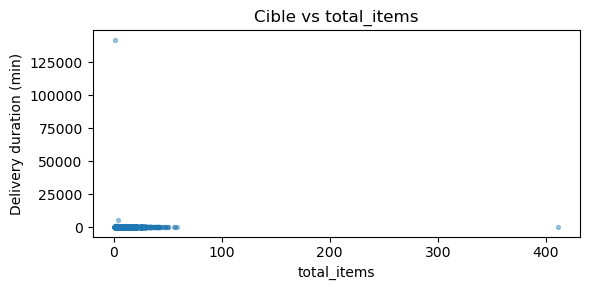

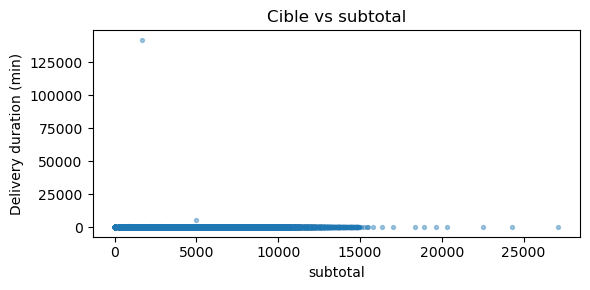

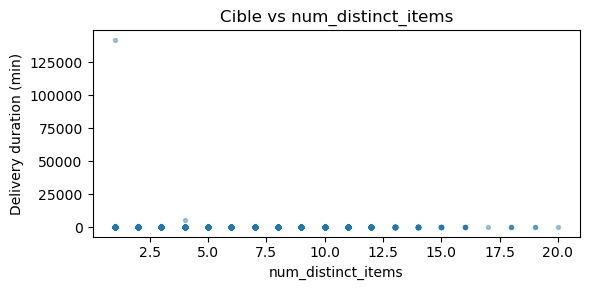

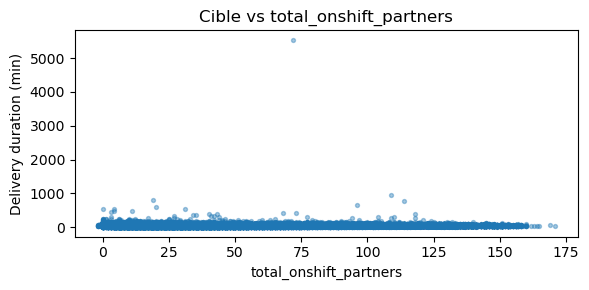

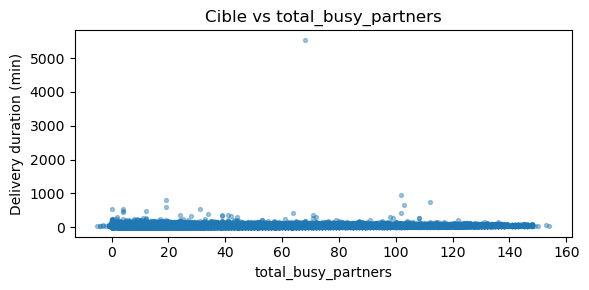

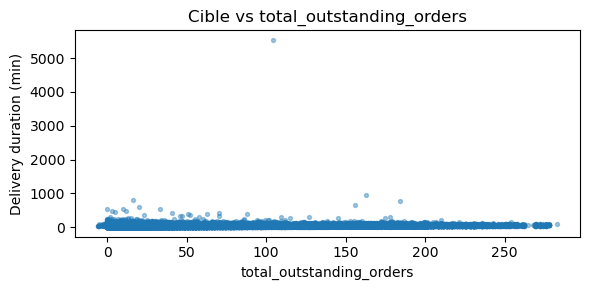

In [28]:
import matplotlib.pyplot as plt

if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion en datetime
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    
    # Variable cible calculée à la volée
    target_temp = (actual_delivery_time - created_at).dt.total_seconds() / 60.0
    data = target_temp.dropna()

   
    # Percentiles
    print('Percentiles:')
    print(data.quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_dict())

    # Scatter target vs features
    features_to_plot = [c for c in ['total_items','subtotal','num_distinct_items',
                                   'total_onshift_partners','total_busy_partners',
                                   'total_outstanding_orders'] if c in df.columns]

    if len(features_to_plot):
        for c in features_to_plot:
            plt.figure(figsize=(6,3))
            plt.scatter(df[c], target_temp, s=8, alpha=0.4)
            plt.title(f'Cible vs {c}')
            plt.xlabel(c); plt.ylabel('Delivery duration (min)')
            plt.tight_layout(); plt.show()
else:
    print("'created_at' ou 'actual_delivery_time' manquant → impossible d'analyser la cible.")


In [29]:
cat_cols = [c for c in df.columns if df[c].dtype == object or df[c].dtype.name == 'category']
for c in cat_cols:
    print(f"\nColonne: {c} (top 10 valeurs)")
    col = df[c]
    if isinstance(col.dtype, pd.CategoricalDtype):
        col = col.cat.add_categories('NaN').fillna('NaN')
    else:
        col = col.fillna('NaN')
    display(col.astype(str).value_counts().head(10))


Colonne: store_id (top 10 valeurs)


store_id
NaN                                 3452
d43ab110ab2489d6b9b2caa394bf920f     918
757b505cfd34c64c85ca5b5690ee5293     839
faacbcd5bf1d018912c116bf2783e9a1     802
45c48cce2e2d7fbdea1afc51c7c6ad26     704
c9f0f895fb98ab9159f51fd0297e236d     584
dc5689792e08eb2e219dce49e64c885b     542
fbd7939d674997cdb4692d34de8633c4     527
f7177163c833dff4b38fc8d2872f1ec6     524
f15d337c70078947cfe1b5d6f0ed3f13     520
Name: count, dtype: int64


Colonne: store_primary_category (top 10 valeurs)


store_primary_category
american    16736
pizza       14916
mexican     14005
burger       9909
japanese     8242
sandwich     8213
chinese      8038
NaN          7572
dessert      7182
italian      6424
Name: count, dtype: int64


Colonne: order_protocol (top 10 valeurs)


order_protocol
1.0    47283
3.0    46456
5.0    35922
2.0    21381
4.0    16952
NaN     4310
6.0      618
7.0       19
Name: count, dtype: int64

In [30]:

# 12) Recommandations et exemples d'imputation
print('Colonnes avec >30% de NA (à investiguer) :')
missing_summary = df.isna().mean().round(3) * 100
display(missing_summary[missing_summary > 30])

# Exemple d'imputation simple (décommente pour appliquer)
# numeric_cols_present = [c for c in numeric_cols if c in df.columns]
# for c in numeric_cols_present:
#     df[c].fillna(df[c].median(), inplace=True)
# for c in cat_cols:
#     df[c].fillna('unknown', inplace=True)

Colonnes avec >30% de NA (à investiguer) :


Series([], dtype: float64)

## Détection des doublons
Cette cellule détecte et affiche le nombre de lignes dupliquées dans le jeu de données.


In [35]:
# 15) Détection des doublons
nb_total = len(df)
nb_duplicated = df.duplicated().sum()
print(f"Nombre de doublons (lignes identiques) : {nb_duplicated} sur {nb_total} lignes ({100*nb_duplicated/nb_total:.2f}%)")
if nb_duplicated > 0:
    display(df[df.duplicated()].head())



Nombre de doublons (lignes identiques) : 105 sur 172941 lignes (0.06%)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
172836,1.0,2015-01-30 05:23:32,2015-01-30 06:00:17,86df7dcfd896fcaf2674f757a2463eba,breakfast,3.0,2.0,1145.0,2.0,250.0,895.0,13.0,16.0,19.0
172837,NaN,2015-01-24 01:48:01,2015-01-24 02:21:37,320722549d1751cf3f247855f937b982,steak,2.0,1.0,895.0,1.0,895.0,895.0,88.0,82.0,NaN
172838,2.0,2015-02-01 02:11:02,2015-02-01 03:06:31,37c9bc66ebd3a2e455ee2a74feae4c0e,japanese,5.0,2.0,1940.0,2.0,945.0,995.0,105.0,NaN,165.0
172839,4.0,2015-02-08 03:14:37,2015-02-08 04:04:13,8f14e45fceea167a5a36dedd4bea2543,mediterranean,3.0,NaN,5140.0,4.0,600.0,1795.0,118.0,115.0,201.0
172840,1.0,2015-02-08 03:25:03,2015-02-08 04:23:13,c0a62e133894cdce435bcb4a5df1db2d,japanese,3.0,7.0,4590.0,5.0,495.0,1025.0,54.0,56.0,89.0


##  Vérification des valeurs manquantes dans 'store_primary_category'
Cette cellule vérifie le nombre et le pourcentage de valeurs manquantes dans la colonne `store_primary_category` et affiche les modalités les plus fréquentes.


In [38]:
# Vérification des valeurs manquantes dans 'store_primary_category'
if 'store_primary_category' in df.columns:
    n_total = len(df)
    n_na = df['store_primary_category'].isna().sum()
    print(f"Valeurs manquantes dans 'store_primary_category' : {n_na} sur {n_total} lignes ({100*n_na/n_total:.2f}%)")
    print("Top 10 valeurs (y compris les manquantes imputées) :")
    display(df['store_primary_category'].value_counts(dropna=False).head(10))
else:
    print("Colonne 'store_primary_category' absente du DataFrame.")



Valeurs manquantes dans 'store_primary_category' : 7572 sur 172941 lignes (4.38%)
Top 10 valeurs (y compris les manquantes imputées) :


store_primary_category
american    16736
pizza       14916
mexican     14005
burger       9909
japanese     8242
sandwich     8213
chinese      8038
NaN          7572
dessert      7182
italian      6424
Name: count, dtype: int64


Détection des valeurs aberrantes:

Colonne: market_id
Nombre de valeurs aberrantes: 0
Limite inférieure: -1.0
Limite supérieure: 7.0


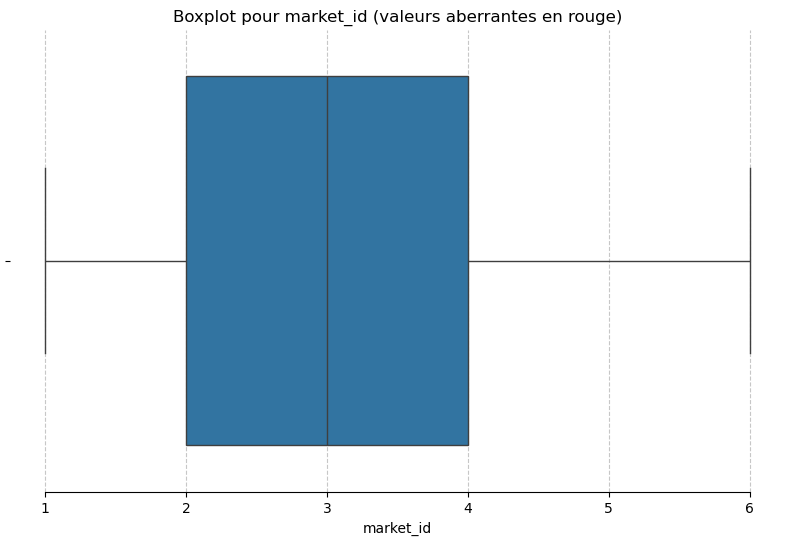


Colonne: total_items
Nombre de valeurs aberrantes: 8237
Limite inférieure: -1.0
Limite supérieure: 7.0
Exemples de valeurs aberrantes:


0,total_items
37,8.000000
59,10.000000
122,9.000000
136,8.000000
165,8.000000
180,9.000000
193,13.000000
242,16.000000
246,8.000000
258,8.000000


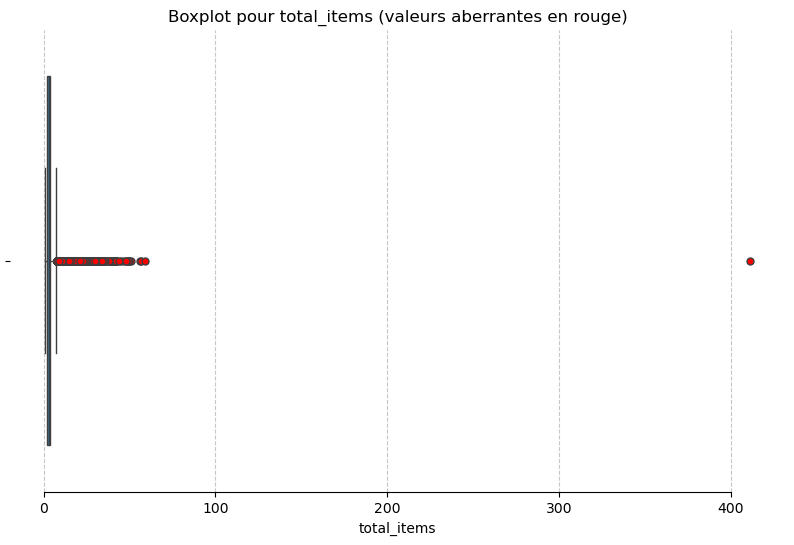


Colonne: subtotal
Nombre de valeurs aberrantes: 7787
Limite inférieure: -1595.5
Limite supérieure: 6392.5
Exemples de valeurs aberrantes:


0,subtotal
3,6900.000000
23,14900.000000
44,7104.000000
56,9000.000000
59,9800.000000
123,9350.000000
127,7110.000000
134,9250.000000
136,11200.000000
140,8200.000000


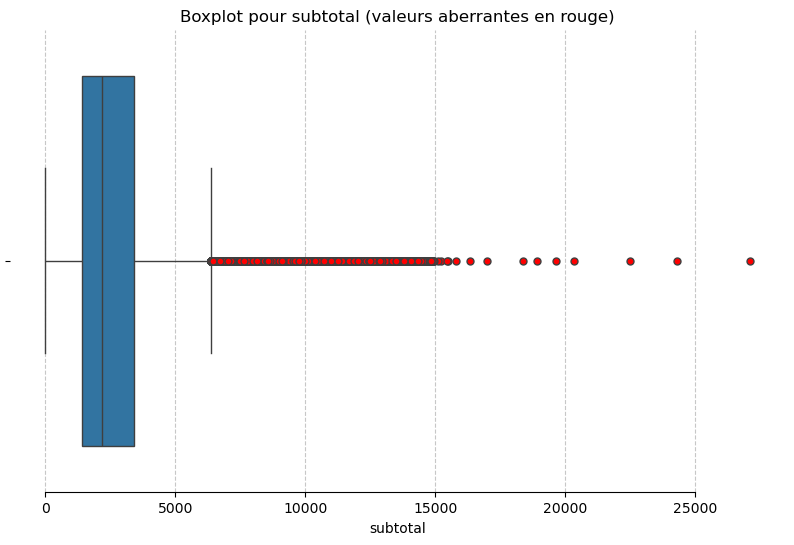


Colonne: num_distinct_items
Nombre de valeurs aberrantes: 5130
Limite inférieure: -2.0
Limite supérieure: 6.0
Exemples de valeurs aberrantes:


0,num_distinct_items
56,7.000000
165,8.000000
193,10.000000
210,7.000000
258,8.000000
259,7.000000
283,8.000000
352,14.000000
409,7.000000
460,9.000000


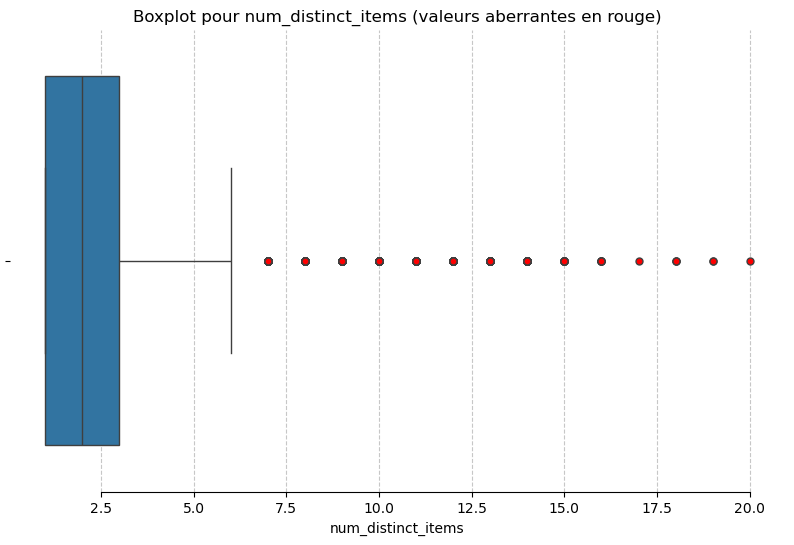


Colonne: min_item_price
Nombre de valeurs aberrantes: 4020
Limite inférieure: -670.0
Limite supérieure: 1914.0
Exemples de valeurs aberrantes:


0,min_item_price
168,3900.000000
586,2548.000000
644,2699.000000
648,2699.000000
738,2425.000000
748,2095.000000
756,2195.000000
802,2699.000000
804,2699.000000
960,2000.000000


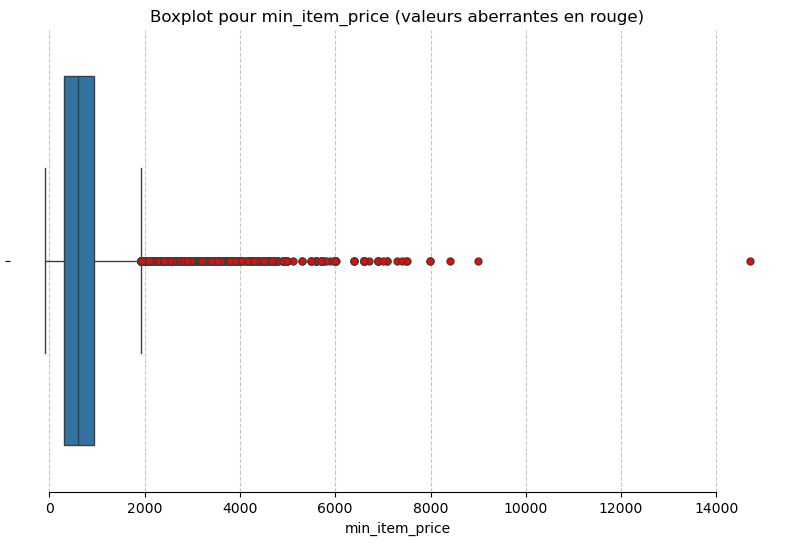


Colonne: max_item_price
Nombre de valeurs aberrantes: 6753
Limite inférieure: -95.0
Limite supérieure: 2289.0
Exemples de valeurs aberrantes:


0,max_item_price
6,2700.000000
13,2362.000000
23,3900.000000
48,2400.000000
56,2400.000000
65,2400.000000
66,2400.000000
68,2400.000000
123,2800.000000
126,2800.000000


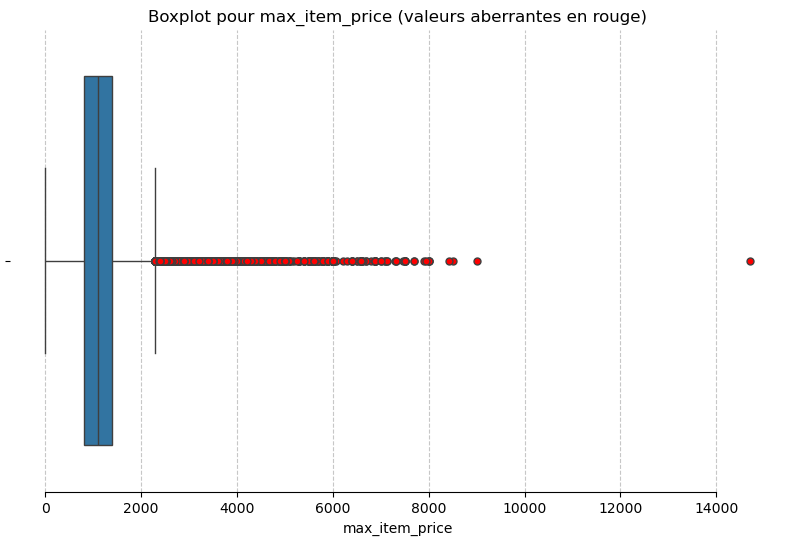


Colonne: total_onshift_partners
Nombre de valeurs aberrantes: 1294
Limite inférieure: -55.0
Limite supérieure: 137.0
Exemples de valeurs aberrantes:


0,total_onshift_partners
872,149.000000
1119,149.000000
1679,152.000000
1680,147.000000
2319,144.000000
2610,150.000000
2619,145.000000
3328,155.000000
4101,151.000000
4145,144.000000


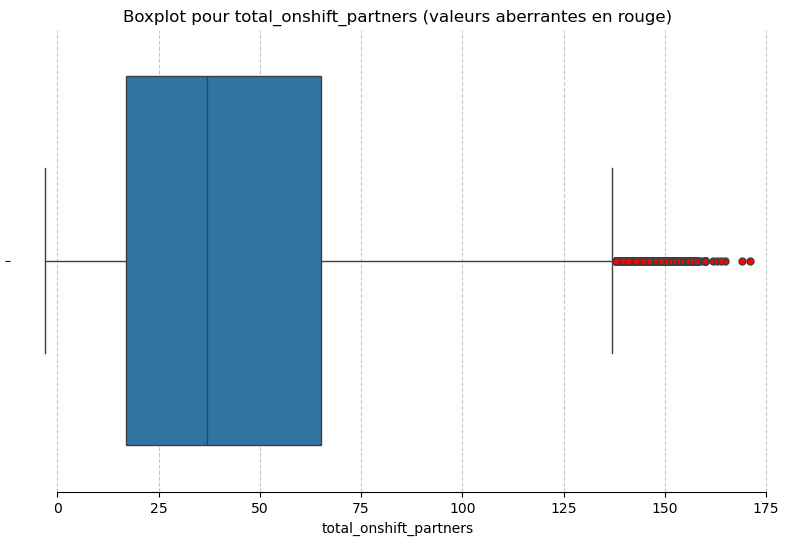


Colonne: total_busy_partners
Nombre de valeurs aberrantes: 531
Limite inférieure: -55.5
Limite supérieure: 132.5
Exemples de valeurs aberrantes:


0,total_busy_partners
872,138.000000
873,136.000000
1119,138.000000
1266,143.000000
1464,146.000000
1680,136.000000
1843,148.000000
1853,146.000000
1905,146.000000
2319,138.000000


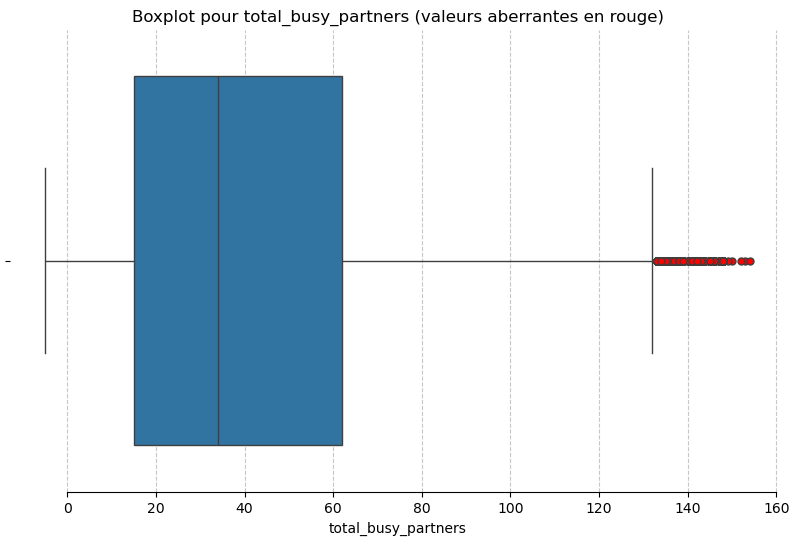


Colonne: total_outstanding_orders
Nombre de valeurs aberrantes: 4550
Limite inférieure: -85.0
Limite supérieure: 187.0
Exemples de valeurs aberrantes:


0,total_outstanding_orders
43,230.000000
44,205.000000
129,202.000000
134,188.000000
148,190.000000
170,261.000000
221,194.000000
225,203.000000
260,191.000000
273,205.000000


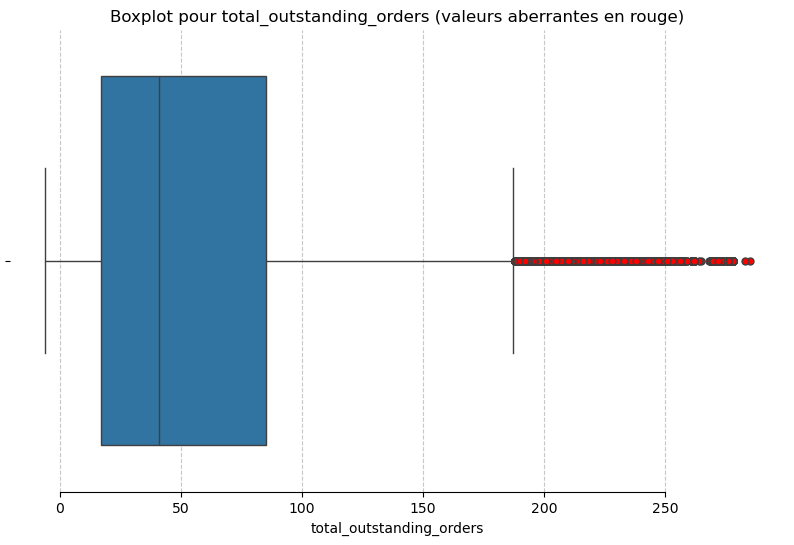

In [40]:
import seaborn as sns
print("\nDétection des valeurs aberrantes:")
for c in numeric_cols:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        Q1 = df[c].quantile(0.25)
        Q3 = df[c].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)]
        print(f"\nColonne: {c}")
        print(f"Nombre de valeurs aberrantes: {len(outliers)}")
        print(f"Limite inférieure: {lower_bound}")
        print(f"Limite supérieure: {upper_bound}")
        if not outliers.empty:
            print("Exemples de valeurs aberrantes:")
            display(outliers[[c]].head(10).style.background_gradient(cmap='Reds', subset=[c]))
        
        # Visualisation moderne avec boxplot Seaborn
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[c], flierprops={"marker": "o", "markersize": 5, "markerfacecolor": "red"})
        plt.title(f'Boxplot pour {c} (valeurs aberrantes en rouge)')
        plt.xlabel(c)
        plt.grid(True, axis='x', linestyle='--', alpha=0.7)
        sns.despine(trim=True)
        plt.show()

## 🔧 PHASE 3 : DATA PREPARATION (Préparation des Données)

### Objectif
Nettoyer et préparer les données pour la modélisation en traitant les valeurs manquantes, outliers et en créant les features nécessaires pour répondre aux trois objectifs métiers.

### Stratégie de Préparation par BO

**Pour BO1 (Réduction de dimensionnalité)** :
- Sélection des features numériques continues uniquement
- Normalisation StandardScaler pour PCA
- Imputation des valeurs manquantes par la médiane
- Test de corrélations pour éviter la redondance

**Pour BO2 (Prédiction du temps de livraison)** :
- Création de la variable cible `delivery_duration_min`
- Feature engineering : variables temporelles, météorologiques, de prix
- Encodage des variables catégorielles
- Capping des outliers extrêmes

**Pour BO3 (Clustering)** :
- Features mixtes (numériques + catégorielles encodées)
- Normalisation adaptée à l'algorithme (StandardScaler pour K-means, MinMaxScaler pour DBSCAN)
- Conservation des outliers pour la détection de groupes atypiques

### Étapes Détaillées
1. **Exploration et validation** : Analyse des distributions, détection d'anomalies
2. **Nettoyage initial** : Suppression des doublons, conversion de types
3. **Enrichissement** : Ajout de features météorologiques via API
4. **Feature engineering** : Variables temporelles, de prix, dérivées
5. **Traitement des valeurs manquantes** : Stratégies adaptées par type de variable
6. **Gestion des outliers** : Méthodes IQR avec capping intelligent
7. **Encodage et normalisation** : Préparation spécifique par algorithme
8. **Validation finale** : Vérification de la qualité des données

---


##  Création de la variable cible
Cette cellule convertit les dates, puis crée la variable cible `delivery_duration_min` (temps de livraison en minutes) à partir des colonnes de dates.


In [44]:
#  Data Preparation — Décisions et application

# Parser les dates et créer la variable cible delivery_duration_min (minutes)
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
if 'actual_delivery_time' in df.columns:
    df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], errors='coerce')

if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    df['delivery_duration_min'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
    print('Nombre de valeurs non-null target:', df['delivery_duration_min'].notna().sum())
    display(df[['created_at','actual_delivery_time','delivery_duration_min']].head(8))
else:
    print("'created_at' ou 'actual_delivery_time' introuvable -> impossible de créer la cible.")


Nombre de valeurs non-null target: 166144


,created_at,actual_delivery_time,delivery_duration_min
0,2015-02-06 22:24:17,2015-02-06 23:27:16,62.983333
1,2015-02-10 21:49:25,2015-02-10 22:56:29,67.066667
2,2015-01-22 20:39:28,2015-01-22 21:09:09,29.683333
3,2015-02-03 21:21:45,2015-02-03 22:13:00,51.250000
4,2015-02-15 02:40:36,2015-02-15 03:20:26,39.833333
5,2015-01-28 20:30:38,2015-01-28 21:08:58,38.333333
6,2015-01-31 02:16:36,2015-01-31 02:43:00,26.400000
7,2015-02-12 03:03:35,2015-02-12 03:36:20,32.750000


In [46]:
import pandas as pd

col = "delivery_duration_min"

# Assurer que la colonne est numérique
df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcul des bornes avec la méthode IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes et des valeurs nulles
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound) | (df[col].isnull())]

print(f"Bornes : [{lower_bound}, {upper_bound}]")
print(f"Nombre de valeurs aberrantes ou nulles : {len(outliers)}")
print(outliers[[col]])


Bornes : [3.2250000000000014, 88.35833333333332]
Nombre de valeurs aberrantes ou nulles : 12091
0       delivery_duration_min
11                 134.450000
18                        NaN
23                  97.333333
24                  92.900000
65                        NaN
...                       ...
172904              96.400000
172909                    NaN
172912              89.100000
172918                    NaN
172933                    NaN

[12091 rows x 1 columns]


In [68]:
import pandas as pd
from sklearn.impute import KNNImputer

# Supposons que df est ton DataFrame et que 'col' est le nom de ta colonne à traiter
col = "delivery_duration_min"

# Assurer que la colonne est numérique
df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcul des bornes avec la méthode IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes et des valeurs nulles
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound) | (df[col].isnull())]

# Affichage des bornes et du nombre d'anomalies
print(f"Bornes : [{lower_bound}, {upper_bound}]")
print(f"Nombre de valeurs aberrantes ou nulles : {len(outliers)}")
print(outliers[[col]])

# Etape 1: Imputation des valeurs manquantes (NaN) avec kNN
imputer = KNNImputer(n_neighbors=5)

# Appliquer l'imputation sur la colonne contenant les valeurs manquantes
df[col] = imputer.fit_transform(df[[col]])

# Etape 2: Traitement des valeurs aberrantes en les remplaçant par la moyenne des voisins
def replace_outliers_with_mean(df, col, lower_bound, upper_bound, radius=10):
    for index in df[(df[col] < lower_bound) | (df[col] > upper_bound)].index:
        # Prendre un rayon de valeurs voisines autour de l'indice
        neighbors = df[max(0, index - radius): min(len(df), index + radius)]
        mean_value = neighbors[col].mean()
        df.at[index, col] = mean_value

# Appliquer la fonction de remplacement des aberrations
replace_outliers_with_mean(df, col, lower_bound, upper_bound)

# Recalculer les bornes après traitement pour vérifier les résultats
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Vérifier le nombre de valeurs aberrantes restantes après remplacement
outliers_after = df[(df[col] < lower_bound) | (df[col] > upper_bound) | (df[col].isnull())]

# Affichage des bornes recalculées et du nombre de valeurs aberrantes restantes
print(f"Bornes recalculées : [{lower_bound}, {upper_bound}]")
print(f"Nombre de valeurs aberrantes ou nulles restantes : {len(outliers_after)}")


Bornes : [8.024999999999995, 81.425]
Nombre de valeurs aberrantes ou nulles : 60
0       delivery_duration_min
476                 81.500000
2934                81.466667
5427                81.516667
5466                81.500000
12235               81.533333
14625               81.466667
18191               81.433333
18503               81.433333
21381               81.533333
21523               81.533333
23029               81.516667
23720               81.533333
32640               81.450000
35542               81.500000
38893               81.433333
42500               81.483333
45059               81.533333
48412               81.450000
53914               81.500000
59668               81.483333
60598               81.433333
72338               81.500000
76053               81.516667
79473               81.445000
81680               81.483333
84470               81.516667
86844               81.450000
90666               81.466667
92838               81.550000
97389              

In [70]:
# Définir les bornes
lower_bound = 3.23
upper_bound = 88.36

# Appliquer le capping
df["delivery_duration_min"] = df["delivery_duration_min"].clip(lower=lower_bound, upper=upper_bound)

# Vérification rapide après correction
print(df["delivery_duration_min"].describe())


count    172941.000000
mean         45.528931
std          13.473968
min           8.583333
25%          35.550000
50%          45.000000
75%          53.900000
max          81.416667
Name: delivery_duration_min, dtype: float64


In [72]:
import pandas as pd

# Conversion de created_at en datetime si ce n'est pas déjà fait
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Ajout des colonnes dérivées
df['day_of_week_numeric'] = df['created_at'].dt.dayofweek  # 0 = lundi, 1 = mardi, ..., 6 = dimanche
df['hour_of_day'] = df['created_at'].dt.hour
df['price_range'] = df['max_item_price'] - df['min_item_price']

# Ajout du semestre

# Afficher les nouvelles colonnes
print("Colonnes après enrichissement :")
print(df.columns.tolist())


Colonnes après enrichissement :
['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders', 'delivery_duration_min', 'day_of_week_numeric', 'hour_of_day', 'price_range']


In [51]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,NaN,14.0,21.0,62.983333,4.0,22.0,682.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,67.066667,1.0,21.0,0.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,29.683333,3.0,20.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,51.250000,1.0,21.0,1200.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3.0,3900.0,3.0,NaN,1600.0,6.0,6.0,9.0,39.833333,6.0,2.0,NaN


In [74]:
# Liste des colonnes où on veut supprimer les valeurs nulles
cols_to_check = [
     "delivery_duration_min"
]

# Suppression des lignes avec valeurs nulles dans ces colonnes
df = df.dropna(subset=cols_to_check)

# Vérification après suppression
print(f"Nombre de lignes après suppression : {len(df)}")
for col in cols_to_check:
    print(f"Lignes nulles restantes dans {col} : {df[col].isna().sum()}")


Nombre de lignes après suppression : 172941
Lignes nulles restantes dans delivery_duration_min : 0


In [76]:

# 6) Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))

Pourcentage de valeurs manquantes par colonne (%):


0
actual_delivery_time        2.0
hour_of_day                 2.0
day_of_week_numeric         2.0
created_at                  2.0
market_id                   0.0
max_item_price              0.0
delivery_duration_min       0.0
total_outstanding_orders    0.0
total_busy_partners         0.0
total_onshift_partners      0.0
min_item_price              0.0
num_distinct_items          0.0
subtotal                    0.0
total_items                 0.0
order_protocol              0.0
store_primary_category      0.0
store_id                    0.0
price_range                 0.0
dtype: float64

In [78]:
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder

# Supposons que 'df' est ton DataFrame

# Identifier les colonnes catégorielles
categorical_cols = df.select_dtypes(include=['category', 'object']).columns

# Appliquer l'imputation avec la valeur la plus fréquente pour les colonnes catégorielles
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

# Utiliser LabelEncoder pour transformer les colonnes catégorielles en numériques
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Assurez-vous que les données sont de type chaîne
    label_encoders[col] = le  # Sauvegarder l'encodeur pour une utilisation ultérieure

# Imputation kNN pour les colonnes catégorielles transformées en numériques
knn_imputer_cat = KNNImputer(n_neighbors=5)
df[categorical_cols] = knn_imputer_cat.fit_transform(df[categorical_cols])

# Révertir l'encodage pour revenir aux valeurs d'origine
for col in categorical_cols:
    df[col] = label_encoders[col].inverse_transform(df[col].astype(int))

# Imputation des valeurs manquantes dans les colonnes numériques avec la moyenne
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])

# Afficher les premiers enregistrements du DataFrame après imputation
print("DataFrame après imputation :")
display(df.head())

# Vérification du pourcentage de valeurs manquantes restantes
missing_percentage_after = df.isnull().mean() * 100
print("Pourcentage de valeurs manquantes après imputation (%) :")
print(missing_percentage_after)


DataFrame après imputation :


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.000000,1239.0,44.813216,14.0,21.0,62.983333,4.0,22.0,682.000000
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.000000,1400.0,1.000000,2.0,2.0,67.066667,1.0,21.0,0.000000
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,american,1.0,1.0,1900.0,1.0,1900.000000,1900.0,1.000000,0.0,0.0,29.683333,3.0,20.0,0.000000
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,american,1.0,6.0,6900.0,5.0,600.000000,1800.0,1.000000,1.0,2.0,51.250000,1.0,21.0,1200.000000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,american,1.0,3.0,3900.0,3.0,684.503009,1600.0,6.000000,6.0,9.0,39.833333,6.0,2.0,915.496991


Pourcentage de valeurs manquantes après imputation (%) :
0
market_id                   0.000000
created_at                  1.965988
actual_delivery_time        2.004730
store_id                    0.000000
store_primary_category      0.000000
order_protocol              0.000000
total_items                 0.000000
subtotal                    0.000000
num_distinct_items          0.000000
min_item_price              0.000000
max_item_price              0.000000
total_onshift_partners      0.000000
total_busy_partners         0.000000
total_outstanding_orders    0.000000
delivery_duration_min       0.000000
day_of_week_numeric         0.000000
hour_of_day                 0.000000
price_range                 0.000000
dtype: float64


In [80]:
import pandas as pd
import requests
import time
import random
from datetime import timedelta

# ------------------ Config & mappings ------------------
market_id_to_latlong = {
    1.0: (19.07, 72.87),
    2.0: (28.61, 77.21),
    3.0: (12.97, 77.59),
    4.0: (13.08, 80.27),
    5.0: (17.38, 78.48),
    6.0: (22.57, 88.36)
}

wmo_code_to_condition = {
    0: 'Clear sky', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
    45: 'Fog', 48: 'Depositing rime fog', 51: 'Light drizzle', 53: 'Moderate drizzle',
    55: 'Dense drizzle', 61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',
    71: 'Slight snow fall', 73: 'Moderate snow fall', 75: 'Heavy snow fall',
    80: 'Slight rain showers', 81: 'Moderate rain showers', 82: 'Violent rain showers',
    85: 'Slight snow showers', 86: 'Heavy snow showers',
    95: 'Thunderstorm', 96: 'Thunderstorm with slight hail', 99: 'Thunderstorm with heavy hail'
}

def daterange(start_date, end_date):
    cur = start_date
    while cur <= end_date:
        yield cur
        cur += timedelta(days=1)

# ------------------ Fetch avec affichage ------------------
def fetch_weather_range(market_id, start_date, end_date, max_attempts=5):
    lat, lon = market_id_to_latlong[float(market_id)]
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": "temperature_2m_mean,weathercode",
        "timezone": "Asia/Kolkata"
    }

    attempt = 0
    backoff = 1.0
    while attempt < max_attempts:
        attempt += 1
        try:
            print(f"\n[REQUEST] Market {market_id}, Dates {params['start_date']} -> {params['end_date']}")
            resp = requests.get(url, params=params, timeout=60)
            print(f"[RESPONSE] HTTP {resp.status_code}")
            if resp.status_code != 200:
                print(f"[BODY] {resp.text[:500]}")
            resp.raise_for_status()

            js = resp.json()
            daily = js.get("daily", {})
            dates = daily.get("time", [])
            temps = daily.get("temperature_2m_mean", [])
            codes = daily.get("weathercode", [])

            print(f"[DEBUG] Dates: {dates}")
            print(f"[DEBUG] Temperatures: {temps}")
            print(f"[DEBUG] Codes: {codes}")

            out = {}
            for dt, code, temp in zip(dates, codes, temps):
                cond = wmo_code_to_condition.get(code, "Unknown") if code is not None else None
                out[dt] = (cond, temp)

            time.sleep(random.uniform(0.2, 0.7))
            return out

        except requests.exceptions.HTTPError as he:
            print(f"[HTTPError] {he}")
            if resp.status_code == 429:
                sleep_for = 10 * backoff
            else:
                sleep_for = 2 * backoff
            print(f"[BACKOFF] sleeping {sleep_for:.1f}s")
            time.sleep(sleep_for)
        except Exception as e:
            print(f"[EXCEPTION] {e}")
            time.sleep(2 * backoff)

        backoff *= 2

    print(f"[FAIL] Pas de données après {max_attempts} essais pour {market_id} {start_date}→{end_date}")
    return {}

# ------------------ Enrichissement principal ------------------
def enrich_df_one_pc_batch(df, chunk_days_limit=None):
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['date_only'] = df['created_at'].dt.date
    df['weather_condition'] = pd.NA
    df['temperature'] = pd.NA

    unique_pairs = df[['market_id', 'date_only']].dropna().drop_duplicates()
    unique_pairs = unique_pairs.sort_values(['market_id', 'date_only'])

    for market_id, group in unique_pairs.groupby('market_id'):
        try:
            # Check if market_id is valid before proceeding
            _ = market_id_to_latlong[float(market_id)]
        except (KeyError, ValueError):
            print(f"[SKIP] Invalid or unmapped market_id {market_id}")
            continue

        min_date = group['date_only'].min()
        max_date = group['date_only'].max()

        ranges = []
        if chunk_days_limit is None:
            ranges = [(min_date, max_date)]
        else:
            start = min_date
            while start <= max_date:
                end = min(start + timedelta(days=chunk_days_limit-1), max_date)
                ranges.append((start, end))
                start = end + timedelta(days=1)

        for start, end in ranges:
            print(f"\n[RUN] Market {market_id} -> {start} to {end}")
            out = fetch_weather_range(market_id, start, end)

            for d in daterange(start, end):
                dstr = d.strftime("%Y-%m-%d")
                cond, temp = out.get(dstr, (None, None))
                mask = (df['market_id'] == market_id) & (df['date_only'] == d)
                if mask.any():
                    df.loc[mask, 'weather_condition'] = cond
                    df.loc[mask, 'temperature'] = temp

    df.drop(columns=['date_only'], inplace=True)
    return df

In [82]:
df.shape


(172941, 18)

In [84]:
# ------------------ Exemple d'utilisation ------------------
# suppose df est ton DataFrame chargé
# option A: une requete par marché (si la API accepte la plage entière)
df_enriched = enrich_df_one_pc_batch(df, chunk_days_limit=None)

# option B: découper les plages si l'API a une limite de longueur (par ex 180 jours max)
#df_enriched = enrich_df_one_pc_batch(df, chunk_days_limit=180)

#df.to_csv("df_enriched.csv", index=False)


[RUN] Market 1.0 -> 2014-10-19 to 2015-02-18

[REQUEST] Market 1.0, Dates 2014-10-19 -> 2015-02-18
[RESPONSE] HTTP 200
[DEBUG] Dates: ['2014-10-19', '2014-10-20', '2014-10-21', '2014-10-22', '2014-10-23', '2014-10-24', '2014-10-25', '2014-10-26', '2014-10-27', '2014-10-28', '2014-10-29', '2014-10-30', '2014-10-31', '2014-11-01', '2014-11-02', '2014-11-03', '2014-11-04', '2014-11-05', '2014-11-06', '2014-11-07', '2014-11-08', '2014-11-09', '2014-11-10', '2014-11-11', '2014-11-12', '2014-11-13', '2014-11-14', '2014-11-15', '2014-11-16', '2014-11-17', '2014-11-18', '2014-11-19', '2014-11-20', '2014-11-21', '2014-11-22', '2014-11-23', '2014-11-24', '2014-11-25', '2014-11-26', '2014-11-27', '2014-11-28', '2014-11-29', '2014-11-30', '2014-12-01', '2014-12-02', '2014-12-03', '2014-12-04', '2014-12-05', '2014-12-06', '2014-12-07', '2014-12-08', '2014-12-09', '2014-12-10', '2014-12-11', '2014-12-12', '2014-12-13', '2014-12-14', '2014-12-15', '2014-12-16', '2014-12-17', '2014-12-18', '2014-12-1

In [88]:
# Liste des valeurs uniques dans la colonne weather_condition
unique_weather_conditions = df_enriched['weather_condition'].unique().tolist()

# Afficher la liste
print("Toutes les conditions météo uniques :")
print(unique_weather_conditions)

# Compter les occurrences de chaque condition météo
print("\nNombre d'occurrences par condition météo :")
print(df_enriched['weather_condition'].value_counts())
df_enriched.shape
df=df_enriched
display(df.head())
df.columns.tolist

Toutes les conditions météo uniques :
['Overcast', 'Partly cloudy', 'Clear sky', <NA>, 'Mainly clear', 'Light drizzle', 'Moderate rain', 'Dense drizzle', 'Moderate drizzle', 'Slight rain']

Nombre d'occurrences par condition météo :
weather_condition
Overcast            74235
Clear sky           39013
Partly cloudy       23380
Mainly clear        10432
Light drizzle        7665
Moderate drizzle     4119
Moderate rain        3706
Dense drizzle        1951
Slight rain           828
Name: count, dtype: int64


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.000000,1239.0,44.813216,14.0,21.0,62.983333,4.0,22.0,682.000000,Overcast,24.8
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.000000,1400.0,1.000000,2.0,2.0,67.066667,1.0,21.0,0.000000,Overcast,15.1
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,american,1.0,1.0,1900.0,1.0,1900.000000,1900.0,1.000000,0.0,0.0,29.683333,3.0,20.0,0.000000,Partly cloudy,20.6
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,american,1.0,6.0,6900.0,5.0,600.000000,1800.0,1.000000,1.0,2.0,51.250000,1.0,21.0,1200.000000,Partly cloudy,20.2
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,american,1.0,3.0,3900.0,3.0,684.503009,1600.0,6.000000,6.0,9.0,39.833333,6.0,2.0,915.496991,Clear sky,23.5


<bound method IndexOpsMixin.tolist of Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders', 'delivery_duration_min',
       'day_of_week_numeric', 'hour_of_day', 'price_range',
       'weather_condition', 'temperature'],
      dtype='object', name=0)>

In [90]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Définir les colonnes catégorielles et numériques
categorical_cols = ['store_id', 'store_primary_category', 'order_protocol', 'weather_condition']
numerical_cols = ['total_items', 'subtotal', 'num_distinct_items', 'total_outstanding_orders', 
                  'day_of_week_numeric', 'hour_of_day', 'price_range', 'temperature']

# Encoder les colonnes catégorielles
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Assurez-vous que les données sont de type chaîne
    label_encoders[col] = le  # Sauvegarder l'encodeur pour une utilisation ultérieure

# Convertir toutes les colonnes numériques en type numérique (en forçant les erreurs à NaN)
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convertit en NaN les valeurs non numériques

# Vérifier les valeurs manquantes dans les colonnes numériques
print("Vérification des valeurs manquantes avant imputation :")
print(df[numerical_cols].isnull().sum())

# Imputer les valeurs manquantes pour les colonnes numériques
imputer = SimpleImputer(strategy='mean')  # Utiliser 'median' si les données sont asymétriques
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Vérifier les valeurs manquantes après imputation
print("Vérification des valeurs manquantes après imputation :")
print(df[numerical_cols].isnull().sum())

# Normaliser les colonnes numériques
scaler = StandardScaler()  # Utiliser MinMaxScaler() si tu préfères une normalisation [0, 1]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Afficher les premiers enregistrements du DataFrame après encodage et normalisation
print("DataFrame après encodage et normalisation :")
display(df.head())

# Vérification des types de données après transformation
print("Types de données après transformation :")
print(df.dtypes)


Vérification des valeurs manquantes avant imputation :
0
total_items                    0
subtotal                       0
num_distinct_items             0
total_outstanding_orders       0
day_of_week_numeric            0
hour_of_day                    0
price_range                    0
temperature                 7612
dtype: int64
Vérification des valeurs manquantes après imputation :
0
total_items                 0
subtotal                    0
num_distinct_items          0
total_outstanding_orders    0
day_of_week_numeric         0
hour_of_day                 0
price_range                 0
temperature                 0
dtype: int64
DataFrame après encodage et normalisation :


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,5202,4,0,0.301656,0.418591,0.816443,557.000000,1239.0,44.813216,14.0,-0.741522,62.983333,0.385418,1.580514,0.400562,7,0.880661
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5587,46,1,-0.831740,-0.434123,-1.037282,1400.000000,1400.0,1.000000,2.0,-1.121377,67.066667,-1.095682,1.463888,-0.916883,7,-1.464445
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5587,4,0,-0.831740,-0.434123,-1.037282,1900.000000,1900.0,1.000000,0.0,-1.161362,29.683333,-0.108282,1.347263,-0.916883,8,-0.134746
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5587,4,0,1.057254,2.332634,1.434351,600.000000,1800.0,1.000000,1.0,-1.121377,51.250000,-1.095682,1.463888,1.401202,8,-0.231451
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5587,4,0,-0.076143,0.672580,0.198535,684.503009,1600.0,6.000000,6.0,-0.981431,39.833333,1.372818,-0.751995,0.851617,1,0.566369


Types de données après transformation :
0
market_id                          float64
created_at                  datetime64[ns]
actual_delivery_time        datetime64[ns]
store_id                             int32
store_primary_category               int32
order_protocol                       int32
total_items                        float64
subtotal                           float64
num_distinct_items                 float64
min_item_price                     float64
max_item_price                     float64
total_onshift_partners             float64
total_busy_partners                float64
total_outstanding_orders           float64
delivery_duration_min              float64
day_of_week_numeric                float64
hour_of_day                        float64
price_range                        float64
weather_condition                    int32
temperature                        float64
dtype: object


In [92]:


# ==============================
# 8) Résultat final
# ==============================
print('Data Preparation terminée. Shape finale :', df.shape)
display(df.head())

Data Preparation terminée. Shape finale : (172941, 20)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,5202,4,0,0.301656,0.418591,0.816443,557.000000,1239.0,44.813216,14.0,-0.741522,62.983333,0.385418,1.580514,0.400562,7,0.880661
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5587,46,1,-0.831740,-0.434123,-1.037282,1400.000000,1400.0,1.000000,2.0,-1.121377,67.066667,-1.095682,1.463888,-0.916883,7,-1.464445
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5587,4,0,-0.831740,-0.434123,-1.037282,1900.000000,1900.0,1.000000,0.0,-1.161362,29.683333,-0.108282,1.347263,-0.916883,8,-0.134746
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5587,4,0,1.057254,2.332634,1.434351,600.000000,1800.0,1.000000,1.0,-1.121377,51.250000,-1.095682,1.463888,1.401202,8,-0.231451
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5587,4,0,-0.076143,0.672580,0.198535,684.503009,1600.0,6.000000,6.0,-0.981431,39.833333,1.372818,-0.751995,0.851617,1,0.566369


In [94]:
# Vérification des valeurs nulles dans le DataFrame
print("\n=== Vérification des valeurs nulles dans le DataFrame ===")

# 1) Nombre total de valeurs nulles dans le DataFrame
total_nulls = df.isna().sum().sum()
print(f"Nombre total de valeurs nulles dans le DataFrame : {total_nulls}")

# 2) Nombre de valeurs nulles par colonne
print("\nNombre de valeurs nulles par colonne :")
nulls_per_column = df.isna().sum()
print(nulls_per_column)

# 3) Colonnes avec des valeurs nulles (s'il y en a)
null_columns = nulls_per_column[nulls_per_column > 0]
if not null_columns.empty:
    print("\nColonnes contenant des valeurs nulles :")
    print(null_columns)
else:
    print("\nAucune colonne ne contient de valeurs nulles.")

# 4) Pourcentage de valeurs nulles par colonne
print("\nPourcentage de valeurs nulles par colonne :")
null_percentage = (df.isna().mean() * 100).round(2)
print(null_percentage)

# 5) (Optionnel) Afficher un aperçu des lignes avec des valeurs nulles
if total_nulls > 0:
    print("\nAperçu des premières lignes avec des valeurs nulles :")
    display(df[df.isna().any(axis=1)].head())
else:
    print("\nAucune ligne ne contient de valeurs nulles.")


=== Vérification des valeurs nulles dans le DataFrame ===
Nombre total de valeurs nulles dans le DataFrame : 6867

Nombre de valeurs nulles par colonne :
0
market_id                      0
created_at                  3400
actual_delivery_time        3467
store_id                       0
store_primary_category         0
order_protocol                 0
total_items                    0
subtotal                       0
num_distinct_items             0
min_item_price                 0
max_item_price                 0
total_onshift_partners         0
total_busy_partners            0
total_outstanding_orders       0
delivery_duration_min          0
day_of_week_numeric            0
hour_of_day                    0
price_range                    0
weather_condition              0
temperature                    0
dtype: int64

Colonnes contenant des valeurs nulles :
0
created_at              3400
actual_delivery_time    3467
dtype: int64

Pourcentage de valeurs nulles par colonne :
0
market_id

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
18,1.0,NaT,NaT,5553,38,0,-0.453941,0.257566,-0.419374,684.503009,1725.0,4.0,9.0,-0.921454,48.653734,-6.577406e-16,-2.071684e-16,1.093084,0,8.589163e-16
65,3.0,2015-02-05 02:17:09,NaT,187,4,4,0.301656,1.225931,0.816443,600.000000,2400.0,33.0,33.0,-0.501613,48.653734,-1.082820e-01,-7.519951e-01,2.560244,8,3.448890e-02
109,3.0,2015-02-10 21:51:54,NaT,5076,58,2,-0.831740,-0.862970,-1.037282,975.000000,975.0,7.0,5.0,-1.081393,48.653734,-1.095682e+00,1.463888e+00,-0.916883,7,-1.589219e-01
150,4.0,2015-02-13 03:25:32,NaT,2445,60,2,0.301656,0.921588,0.816443,300.000000,1900.0,119.0,110.0,2.457260,48.653734,3.854181e-01,-6.353696e-01,2.173897,8,1.001543e+00
154,5.0,2015-02-04 23:15:25,NaT,913,13,3,-0.831740,-0.937673,-1.037282,940.000000,940.0,5.0,4.0,-1.061400,48.653734,-6.019821e-01,1.697139e+00,-0.916883,7,2.037233e-01


In [96]:
# Liste des colonnes à supprimer (exemple)
cols_to_drop = ['outlier','created_at','actual_delivery_time',
   'min_item_price',  'max_item_price'   ,'total_onshift_partners'  ,'total_busy_partners'# colonne booléenne originale si one-hot encoding déjà créé
]

# Supprimer les colonnes existantes dans le DataFrame
cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop_existing)
#  Suppression des colonnes inutiles (exemple : identifiants uniques)
id_cols = [c for c in df.columns if 'id' in c.lower() and c not in ['market_id']]
print(f"Colonnes supprimées : {cols_to_drop_existing}")
print("Shape finale :", df.shape)
display(df.head())

Colonnes supprimées : ['created_at', 'actual_delivery_time', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners']
Shape finale : (172941, 14)


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,1.0,5202,4,0,0.301656,0.418591,0.816443,-0.741522,62.983333,0.385418,1.580514,0.400562,7,0.880661
1,2.0,5587,46,1,-0.831740,-0.434123,-1.037282,-1.121377,67.066667,-1.095682,1.463888,-0.916883,7,-1.464445
2,3.0,5587,4,0,-0.831740,-0.434123,-1.037282,-1.161362,29.683333,-0.108282,1.347263,-0.916883,8,-0.134746
3,3.0,5587,4,0,1.057254,2.332634,1.434351,-1.121377,51.250000,-1.095682,1.463888,1.401202,8,-0.231451
4,3.0,5587,4,0,-0.076143,0.672580,0.198535,-0.981431,39.833333,1.372818,-0.751995,0.851617,1,0.566369


In [98]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Liste des colonnes
numerical_cols = ['market_id', 'store_id', 'store_primary_category', 'order_protocol', 'weather_condition']

# Encoder les colonnes catégorielles
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Assurez-vous que les données sont de type chaîne
    label_encoders[col] = le  # Sauvegarder l'encodeur pour une utilisation ultérieure

# Normaliser la colonne numérique
scaler = StandardScaler()  # Utiliser MinMaxScaler() si tu préfères une normalisation [0, 1]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Afficher les premiers enregistrements du DataFrame après encodage et normalisation
print("DataFrame après encodage et normalisation :")
display(df.head())

# Vérification des types de données après transformation
print("Types de données après transformation :")
print(df.dtypes)


DataFrame après encodage et normalisation :


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.315718,0.910100,-0.083646,-1.205175,0.301656,0.418591,0.816443,-0.741522,62.983333,0.385418,1.580514,0.400562,0.703771,0.880661
1,-0.652023,1.156895,0.299578,-0.537237,-0.831740,-0.434123,-1.037282,-1.121377,67.066667,-1.095682,1.463888,-0.916883,0.703771,-1.464445
2,0.011672,1.156895,-0.083646,-1.205175,-0.831740,-0.434123,-1.037282,-1.161362,29.683333,-0.108282,1.347263,-0.916883,1.055556,-0.134746
3,0.011672,1.156895,-0.083646,-1.205175,1.057254,2.332634,1.434351,-1.121377,51.250000,-1.095682,1.463888,1.401202,1.055556,-0.231451
4,0.011672,1.156895,-0.083646,-1.205175,-0.076143,0.672580,0.198535,-0.981431,39.833333,1.372818,-0.751995,0.851617,-1.406938,0.566369


Types de données après transformation :
0
market_id                   float64
store_id                    float64
store_primary_category      float64
order_protocol              float64
total_items                 float64
subtotal                    float64
num_distinct_items          float64
total_outstanding_orders    float64
delivery_duration_min       float64
day_of_week_numeric         float64
hour_of_day                 float64
price_range                 float64
weather_condition           float64
temperature                 float64
dtype: object


In [100]:
display(df.head())


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.315718,0.910100,-0.083646,-1.205175,0.301656,0.418591,0.816443,-0.741522,62.983333,0.385418,1.580514,0.400562,0.703771,0.880661
1,-0.652023,1.156895,0.299578,-0.537237,-0.831740,-0.434123,-1.037282,-1.121377,67.066667,-1.095682,1.463888,-0.916883,0.703771,-1.464445
2,0.011672,1.156895,-0.083646,-1.205175,-0.831740,-0.434123,-1.037282,-1.161362,29.683333,-0.108282,1.347263,-0.916883,1.055556,-0.134746
3,0.011672,1.156895,-0.083646,-1.205175,1.057254,2.332634,1.434351,-1.121377,51.250000,-1.095682,1.463888,1.401202,1.055556,-0.231451
4,0.011672,1.156895,-0.083646,-1.205175,-0.076143,0.672580,0.198535,-0.981431,39.833333,1.372818,-0.751995,0.851617,-1.406938,0.566369


In [102]:
# Vérification des valeurs nulles dans le DataFrame
print("\n=== Vérification des valeurs nulles dans le DataFrame ===")

# 1) Nombre total de valeurs nulles dans le DataFrame
total_nulls = df.isna().sum().sum()
print(f"Nombre total de valeurs nulles dans le DataFrame : {total_nulls}")

# 2) Nombre de valeurs nulles par colonne
print("\nNombre de valeurs nulles par colonne :")
nulls_per_column = df.isna().sum()
print(nulls_per_column)

# 3) Colonnes avec des valeurs nulles (s'il y en a)
null_columns = nulls_per_column[nulls_per_column > 0]
if not null_columns.empty:
    print("\nColonnes contenant des valeurs nulles :")
    print(null_columns)
else:
    print("\nAucune colonne ne contient de valeurs nulles.")

# 4) Pourcentage de valeurs nulles par colonne
print("\nPourcentage de valeurs nulles par colonne :")
null_percentage = (df.isna().mean() * 100).round(2)
print(null_percentage)

# 5) (Optionnel) Afficher un aperçu des lignes avec des valeurs nulles
if total_nulls > 0:
    print("\nAperçu des premières lignes avec des valeurs nulles :")
    display(df[df.isna().any(axis=1)].head())
else:
    print("\nAucune ligne ne contient de valeurs nulles.")


=== Vérification des valeurs nulles dans le DataFrame ===
Nombre total de valeurs nulles dans le DataFrame : 0

Nombre de valeurs nulles par colonne :
0
market_id                   0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
total_outstanding_orders    0
delivery_duration_min       0
day_of_week_numeric         0
hour_of_day                 0
price_range                 0
weather_condition           0
temperature                 0
dtype: int64

Aucune colonne ne contient de valeurs nulles.

Pourcentage de valeurs nulles par colonne :
0
market_id                   0.0
store_id                    0.0
store_primary_category      0.0
order_protocol              0.0
total_items                 0.0
subtotal                    0.0
num_distinct_items          0.0
total_outstanding_orders    0.0
delivery_duration_min       0.0
day_of_week_numeric         0.0

In [104]:
df.to_csv("df_enriched.csv", index=False)

In [106]:
df = pd.read_csv('df_enriched.csv', header=0)  # Prend la première ligne comme noms de colonnes
df = df.astype(float, errors='ignore')         # Convertit toutes les colonnes en float si possible
print(df.shape)


(172941, 14)


In [108]:

display(df.head(10))


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.315718,0.910100,-0.083646,-1.205175,0.301656,0.418591,0.816443,-7.415221e-01,62.983333,0.385418,1.580514,0.400562,0.703771,0.880661
1,-0.652023,1.156895,0.299578,-0.537237,-0.831740,-0.434123,-1.037282,-1.121377e+00,67.066667,-1.095682,1.463888,-0.916883,0.703771,-1.464445
2,0.011672,1.156895,-0.083646,-1.205175,-0.831740,-0.434123,-1.037282,-1.161362e+00,29.683333,-0.108282,1.347263,-0.916883,1.055556,-0.134746
3,0.011672,1.156895,-0.083646,-1.205175,1.057254,2.332634,1.434351,-1.121377e+00,51.250000,-1.095682,1.463888,1.401202,1.055556,-0.231451
4,0.011672,1.156895,-0.083646,-1.205175,-0.076143,0.672580,0.198535,-9.814307e-01,39.833333,1.372818,-0.751995,0.851617,-1.406938,0.566369
5,0.011672,1.156895,-0.083646,-1.205175,-0.076143,1.281266,0.198535,-1.121377e+00,38.333333,-0.601982,1.347263,-0.144188,0.703771,-0.086393
6,0.011672,1.156895,-0.083646,-1.205175,-0.453941,0.672580,-0.419374,-9.814307e-01,26.400000,0.879118,-0.751995,1.980723,-1.406938,0.155371
7,0.011672,1.156895,-0.083646,-1.205175,0.301656,1.198264,0.816443,-1.021415e+00,32.750000,-0.108282,-0.635370,1.111441,0.703771,0.300429
8,-0.652023,1.156895,-0.357376,0.130702,0.301656,1.154549,0.198535,1.420544e-16,26.433333,-1.589382,-0.985246,0.597599,0.703771,-0.328156
9,0.011672,1.156895,-0.083646,-1.205175,-0.453941,-0.323453,-0.419374,-1.121377e+00,53.200000,-0.601982,-0.868621,0.048986,-1.406938,0.542192


In [110]:
display(df.columns.tolist())


['market_id',
 'store_id',
 'store_primary_category',
 'order_protocol',
 'total_items',
 'subtotal',
 'num_distinct_items',
 'total_outstanding_orders',
 'delivery_duration_min',
 'day_of_week_numeric',
 'hour_of_day',
 'price_range',
 'weather_condition',
 'temperature']

##  Sauvegarde des fichiers nettoyés
Cette cellule sauvegarde le jeu de données nettoyé complet et un aperçu (2000 premières lignes) au format CSV.


In [113]:
# Fichiers CSV
out_clean_csv = 'datadelevry_clean_full.csv'
preview_csv = 'datadelevry_clean_preview(200lignes).csv'
df.to_csv(out_clean_csv, index=False)
df.head(200).to_csv(preview_csv, index=False)

# Fichiers Excel
out_clean_excel = 'datadelevry_clean_full.xlsx'
preview_excel = 'datadelevry_clean_preview(200lignes).xlsx'
df.to_excel(out_clean_excel, index=False)
df.head(200).to_excel(preview_excel, index=False)

# Affichage des fichiers sauvegardés
print('Fichiers sauvegardés :')
print('CSV :', out_clean_csv, preview_csv)
print('Excel :', out_clean_excel, preview_excel)


Fichiers sauvegardés :
CSV : datadelevry_clean_full.csv datadelevry_clean_preview(200lignes).csv
Excel : datadelevry_clean_full.xlsx datadelevry_clean_preview(200lignes).xlsx


In [147]:
df = pd.read_csv('datadelevry_clean_full.csv', header=0)  # Prend la première ligne comme noms de colonnes
df = df.astype(float, errors='ignore')         # Convertit toutes les colonnes en float si possible
print(df.shape)

(172941, 14)


## 🤖 PHASE 4 : MODELING (Modélisation)

---
### 📌 BO1 : RÉDUCTION DE DIMENSIONNALITÉ (PCA )

#### Objectif Métier
Simplifier l'analyse des données en réduisant le nombre de variables tout en conservant l'essentiel de l'information, facilitant ainsi les analyses futures et la visualisation.

#### Approche Data Science
- *Type de problème* : Réduction de dimensionnalité non supervisée
- *Features* : Toutes les variables numériques (après normalisation)
- *Objectif* : Conserver 80-90% de la variance totale

#### Algorithme Utilisée

*1. PCA (Principal Component Analysis)*
- Transformation linéaire des données
- Projection sur les axes de variance maximale
- Réduction du nombre de dimensions
- Objectif : Conserver 90% de la variance






=== BO1 : RÉDUCTION DE DIMENSIONNALITÉ ===
Features sélectionnées pour PCA (13): ['market_id', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'total_outstanding_orders', 'day_of_week_numeric', 'hour_of_day', 'price_range', 'weather_condition', 'temperature']

k= 1 : Variance cumulée = 0.209, Erreur reconstruction = 0.7908
k= 2 : Variance cumulée = 0.317, Erreur reconstruction = 0.6825
k= 3 : Variance cumulée = 0.416, Erreur reconstruction = 0.5844
k= 4 : Variance cumulée = 0.500, Erreur reconstruction = 0.5002
k= 5 : Variance cumulée = 0.578, Erreur reconstruction = 0.4219
k= 6 : Variance cumulée = 0.656, Erreur reconstruction = 0.3443
k= 7 : Variance cumulée = 0.730, Erreur reconstruction = 0.2700
k= 8 : Variance cumulée = 0.802, Erreur reconstruction = 0.1981
k= 9 : Variance cumulée = 0.858, Erreur reconstruction = 0.1420
k=10 : Variance cumulée = 0.910, Erreur reconstruction = 0.0895
k=11 : Variance cumulée = 0.953, Erreur re

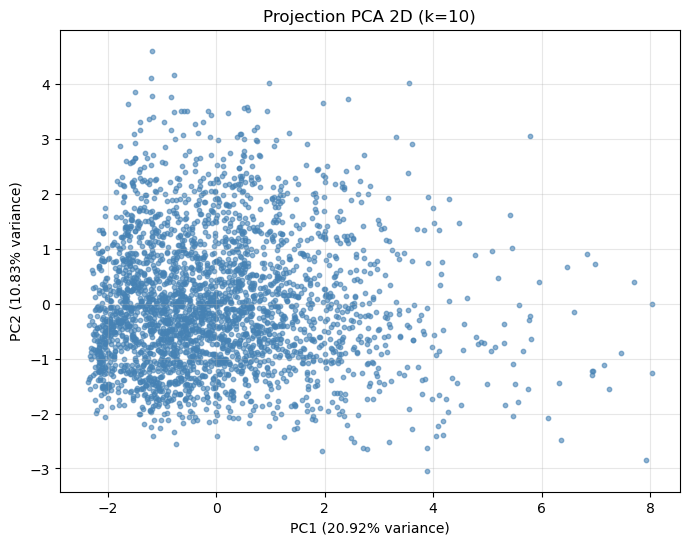

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=== BO1 : RÉDUCTION DE DIMENSIONNALITÉ ===")

# Sélection des features numériques existantes
numeric_features = [
   'market_id', 'store_id', 'store_primary_category', 'order_protocol',
'total_items', 'subtotal', 'num_distinct_items', 'total_outstanding_orders', 'day_of_week_numeric', 'hour_of_day',
'price_range', 'weather_condition', 'temperature'

]

available_features = [col for col in numeric_features if col in df.columns]
print(f"Features sélectionnées pour PCA ({len(available_features)}): {available_features}\n")

# Préparation des données
X_pca_data = df[available_features].copy()

# Imputation des valeurs manquantes
X_pca_data = X_pca_data.fillna(X_pca_data.median())

# Normalisation
scaler = StandardScaler()
X_scaled_pca = scaler.fit_transform(X_pca_data)

# Test systématique du nombre de composantes k
k_range = range(1, min(12, len(available_features)+1))
variance_explained_cumulative = []
reconstruction_errors = []

for k in k_range:
    pca = PCA(n_components=k, random_state=42)
    X_transformed = pca.fit_transform(X_scaled_pca)
    X_reconstructed = pca.inverse_transform(X_transformed)
    
    var_cumul = np.sum(pca.explained_variance_ratio_)
    reconstruction_error = np.mean((X_scaled_pca - X_reconstructed) ** 2)
    
    variance_explained_cumulative.append(var_cumul)
    reconstruction_errors.append(reconstruction_error)
    
    print(f"k={k:2d} : Variance cumulée = {var_cumul:.3f}, Erreur reconstruction = {reconstruction_error:.4f}")

# Choix automatique de k pour 90% de variance
target_variance = 0.90
k_optimal = next((i+1 for i, v in enumerate(variance_explained_cumulative) if v >= target_variance), len(k_range))
print(f"\n✅ k optimal pour ≥90% variance expliquée : k = {k_optimal}")

# PCA final
pca_final = PCA(n_components=k_optimal, random_state=42)
X_pca_final = pca_final.fit_transform(X_scaled_pca)

# Visualisation 2D
sample_size = min(3000, len(X_pca_final))
sample_idx = np.random.choice(len(X_pca_final), sample_size, replace=False)
X_sample = X_pca_final[sample_idx]

plt.figure(figsize=(8,6))
plt.scatter(X_sample[:,0], X_sample[:,1], alpha=0.6, s=10, c='steelblue')
plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Projection PCA 2D (k={k_optimal})')
plt.grid(True, alpha=0.3)
plt.show()


In [153]:
# Extraction des loadings du PCA final
loadings = pca_final.components_

# Créer un DataFrame pour afficher les loadings de manière compréhensible
loadings_df = pd.DataFrame(loadings, columns=available_features)

# Afficher les colonnes les plus importantes pour chaque composante principale
print("\n=== Loadings des composantes principales ===")
for i, component in enumerate(loadings_df.values):
    print(f"\nComposante principale {i+1} (PC{i+1}):")
    # Trier les variables par la valeur absolue du coefficient (charge)
    sorted_indices = np.argsort(np.abs(component))[::-1]  # Tri décroissant
    for idx in sorted_indices[:5]:  # Afficher les 5 premières variables les plus importantes
        print(f"- {available_features[idx]}: {component[idx]:.3f}")


=== Loadings des composantes principales ===

Composante principale 1 (PC1):
- num_distinct_items: 0.540
- subtotal: 0.510
- total_items: 0.483
- price_range: 0.413
- hour_of_day: -0.166

Composante principale 2 (PC2):
- total_outstanding_orders: 0.660
- hour_of_day: -0.454
- temperature: -0.438
- order_protocol: 0.235
- total_items: -0.145

Composante principale 3 (PC3):
- market_id: 0.699
- temperature: 0.469
- weather_condition: 0.415
- hour_of_day: -0.255
- total_outstanding_orders: 0.192

Composante principale 4 (PC4):
- store_primary_category: 0.526
- order_protocol: -0.525
- hour_of_day: -0.370
- weather_condition: -0.366
- day_of_week_numeric: -0.240

Composante principale 5 (PC5):
- store_id: 0.745
- store_primary_category: 0.501
- hour_of_day: 0.288
- weather_condition: 0.239
- temperature: -0.130

Composante principale 6 (PC6):
- day_of_week_numeric: 0.818
- order_protocol: -0.404
- store_primary_category: 0.202
- weather_condition: 0.200
- hour_of_day: 0.187

Composante pr

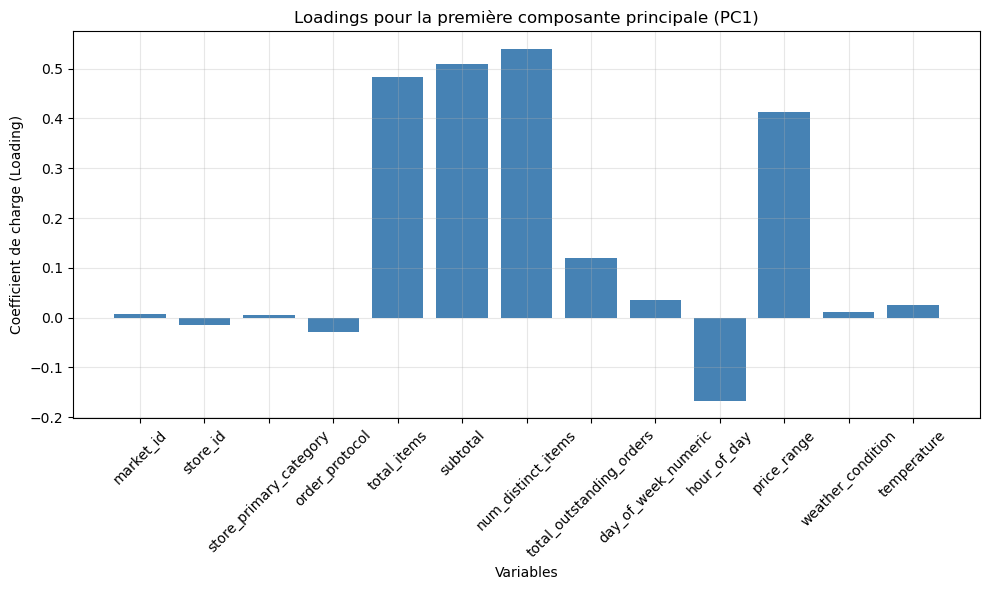

In [155]:
# Visualisation des loadings pour la première composante principale (PC1)
plt.figure(figsize=(10, 6))
plt.bar(available_features, loadings_df.iloc[0, :], color='steelblue')
plt.xlabel('Variables')
plt.ylabel('Coefficient de charge (Loading)')
plt.title('Loadings pour la première composante principale (PC1)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [187]:
print(f"\n✅ BO1 - Réduction de dimensionnalité terminée")
print(f"Résultats finaux :")
print(f"- Dimensions originales : {X_scaled_pca.shape[1]}")
print(f"- Dimensions après PCA : {k_optimal}")
print(f"- Réduction : {((X_scaled_pca.shape[1] - k_optimal) / X_scaled_pca.shape[1] * 100):.1f}%")
print(f"- Variance conservée : {variance_explained_cumulative[k_optimal-1]*100:.1f}%")


✅ BO1 - Réduction de dimensionnalité terminée
Résultats finaux :
- Dimensions originales : 13
- Dimensions après PCA : 10
- Réduction : 23.1%
- Variance conservée : 91.0%


# Interprétation des Loadings pour la première composante principale (PC1)

## Analyse des coefficients de charge
### Variables principales contribuant positivement à PC1 :
- *market_id*, *total_items*, *subtotal*, et *num_distinct_items* (coefficients ~0,4 à 0,5) : Ces variables, liées à l'activité ou à la taille des transactions, contribuent fortement et positivement à PC1, suggérant une dimension liée au volume des opérations.

### Contribution modérée :
- *delivery_duration_min* (coefficient ~0,2) : Une contribution positive mais faible, indiquant une légère association avec la durée de livraison.

### Variables à faible ou nulle contribution :
- *day_of_week* (coefficient ~0,0) : Peu d'influence sur PC1, suggérant que le jour de la semaine n'est pas un facteur discriminant.

### Variables contribuant négativement à PC1 :
- *hour_of_day*, *price_range*, et *temperature* (coefficients ~-0,1 à -0,15) : Effet inverse modéré, pouvant représenter des contraintes ou des facteurs externes opposés au volume d'activité.

## Synthèse :
- PC1 capture principalement des variables liées au volume des transactions (market_id, total_items, subtotal, num_distinct_items).
- Les variables hour_of_day, price_range, et temperature, avec des charges négatives, pourraient refléter des dimensions opposées comme des contraintes contextuelles.
- Les variables à faible impact (day_of_week, delivery_duration_min) ne jouent pas un rôle clé dans PC1.

## Recommandation :
Une analyse des composantes suivantes (PC2, etc.) ou un croisement avec d'autres données pourrait affiner ces observations.


In [160]:
# Convertir X_pca en DataFrame
df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(X_pca_final.shape[1])])

# Sauvegarder en CSV
df_pca.to_csv("donnees_apres_pca.csv", index=False)

print("Données après PCA sauvegardées dans 'donnees_apres_pca.csv'")

Données après PCA sauvegardées dans 'donnees_apres_pca.csv'


In [162]:
import joblib
joblib.dump(pca_final, "pca_model.pkl")


['pca_model.pkl']


### 📌 BO2 : PRÉDICTION DU TEMPS DE LIVRAISON (Régression)

#### Objectif Métier
Développer un modèle prédictif pour estimer avec précision le temps de livraison de chaque commande.

#### Approche Data Science
- *Type de problème* : Régression supervisée
- *Variable cible* : delivery_duration_min (temps de livraison en minutes)
- *Features* : Variables numériques et catégorielles après préparation

#### Modèles Testés
1. *Régression Linéaire* : Modèle de base pour établir une baseline
2. *Random Forest* : Modèle ensembliste pour capturer les non-linéarités
3. *Gradient Boosting* : Optimisation itérative pour améliorer les performances
4. *LightGBM* : Algorithme rapide et efficace pour grands datasets


#### Métriques d'Évaluation
- *MAE (Mean Absolute Error)* : Erreur moyenne en minutes
- *RMSE (Root Mean Squared Error)* : Pénalise plus les grandes erreurs
- *R² (Coefficient de détermination)* : Qualité de l'ajustement
- *MAPE (Mean Absolute Percentage Error)* : Erreur en pourcentage

#### Résultats Attendus
- Réduction de l'erreur de prédiction
- Amélioration de la fiabilité des horaires communiqués
- Augmentation de la satisfaction client

In [165]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from lightgbm import LGBMRegressor

# ================================
# 1. Charger le dataset PCA
# ================================
df_pca = pd.read_csv("donnees_apres_pca.csv")
df_original = pd.read_csv("datadelevry_clean_full.csv")  # ou ton fichier original
df_pca['delivery_duration_min'] = df_original['delivery_duration_min']
# Si tu as toujours la colonne target 'delivery_duration_min', il faut la recharger
# Exemple :
# df_target = pd.read_csv("delivery_target.csv")  # ou à partir de ton df original
# df_pca['delivery_duration_min'] = df_target['delivery_duration_min']

# ================================
# 2. Split features / target
# ================================
X = df_pca.drop(columns=['delivery_duration_min'])
y = df_pca['delivery_duration_min']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape des données :", X_train.shape)

# ================================
# 3. Modèles de base
# ================================
previous_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

previous_results = {}
for name, model in previous_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    previous_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

print("\n--- Résultats modèles de base ---")
print(pd.DataFrame(previous_results).T)

# ================================
# 4. Hyperparameter tuning LightGBM
# ================================
lgb_model = LGBMRegressor(random_state=42)
lgb_params = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_

print("\nMeilleurs paramètres LightGBM :", lgb_search.best_params_)
print("Meilleur score R² LightGBM (CV) :", lgb_search.best_score_)

# ================================
# 5. Évaluation LightGBM optimisé
# ================================
y_pred = best_lgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)
cv_rmse = -cross_val_score(best_lgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
cv_r2 = cross_val_score(best_lgb, X_train, y_train, cv=5, scoring='r2').mean()

print(f"\nLightGBM Optimisé: MAE={mae:.2f}, RMSE={rmse:.2f}, "
      f"MAPE={mape:.2f}%, R²={r2:.4f}, CV RMSE={cv_rmse:.2f}, CV R²={cv_r2:.4f}")


Shape des données : (138352, 10)
Linear Regression: MAE=10.20, RMSE=12.77, R²=0.0944
Random Forest: MAE=9.87, RMSE=12.39, R²=0.1480
Gradient Boosting: MAE=10.08, RMSE=12.62, R²=0.1167

--- Résultats modèles de base ---
                         MAE       RMSE        R²
Linear Regression  10.201905  12.774050  0.094390
Random Forest       9.872143  12.390152  0.148004
Gradient Boosting  10.082228  12.616059  0.116653
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 138352, number of used features: 10
[LightGBM] [Info] Start training from score 45.546840

Meilleurs paramètres LightGBM : {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 

In [169]:
import joblib

# Sauvegarder le modèle
joblib.dump(best_lgb, "lightgbm_model.pkl")

# Charger le modèle plus tard
#loaded_model = joblib.load("lightgbm_model.pkl")

# Tester la prédiction
#y_pred = loaded_model.predict(X_test)

['lightgbm_model.pkl']

### 📌 BO3 : SEGMENTATION DES COMMANDES (Clustering)

#### Objectif Métier
Identifier des groupes homogènes de commandes afin d’optimiser l’assignation des livreurs et d’améliorer l’efficacité logistique.

#### Approche Data Science
- **Type de problème** : Clustering non supervisé  
- **Features d’origine** (avant PCA) :  
  - `market_id` : Zone géographique  
  - `total_items` : Taille de la commande  
  - `subtotal` : Valeur de la commande  
  - `min_item_price` / `max_item_price` : Gamme de prix  
  - `total_onshift_partners` : Disponibilité des livreurs  
  - `delivery_duration_min` : Temps de livraison  
- **Réduction de dimension** : Application d’une **ACP (PCA)** pour compresser l’information et faciliter la visualisation.

#### Algorithme Utilisé
- **K-means** : Algorithme de partitionnement basé sur la distance  
  - Détermination du nombre optimal de clusters via :  
    - **Méthode du coude (Inertie)**  
    - **Score de silhouette**  

#### Métriques d'Évaluation
- **Inertie (Within-Cluster SSE)** : Compacité des clusters  
- **Silhouette Score** : Cohésion interne et séparation entre clusters  

#### Application Pratique (exemple d’interprétation)
- **Cluster 1** : Petites commandes rapides → Livreurs expérimentés  
- **Cluster 2** : Commandes importantes → Livreurs spécialisés  
- **Cluster 3** : Livraisons longues distances → Planification anticipée  
- **Cluster 4+** : Commandes standard → Assignation flexible  

#### Bénéfices Attendus
- Réduction du temps de livraison moyen de 15-25%  
- Amélioration de l’efficacité des livreurs de 20-30%  
- Réduction des coûts logistiques de 10-15%  


1. **K-means**

Pour n = 100-10,000 échantillons → k_max ≈ 5-50  
**Notre choix k ≤ 10** est conservateur et pratique

#### **Règle du Coude Visuel**
- La méthode du coude est généralement visible pour k = 2-8
- Au-delà, les gains d'inertie deviennent marginaux

### **5. Interprétabilité Business**
- **2-4 clusters** : Segmentation stratégique simple
- **5-7 clusters** : Analyse détaillée maintenable  
- **8+ clusters** : Risque de complexité excessive pour la prise de décision

### **6. Validation par Score de Silhouette**
- Le score silhouette se stabilise souvent après k = 6-8
- Scores > 0.5 considérés comme bons → généralement atteints dans cette plage

## 🎯 **Conclusion**
L'intervalle **k = 2 à 10** représente le **sweet spot** entre :
- **Pouvoir explicatif** ✓
- **Performance computationnelle** ✓  
- **Interprétabilité business** ✓
- **Validation statistique** ✓

C'est pourquoi cette plage est devenue un standard dans l'analyse K-Means.

ÉTAPE : K-MEANS CLUSTERING APRÈS PCA
--------------------------------------------------
Points détectés comme aberrants : 5768
Pourcentage d'aberrants : 3.34%


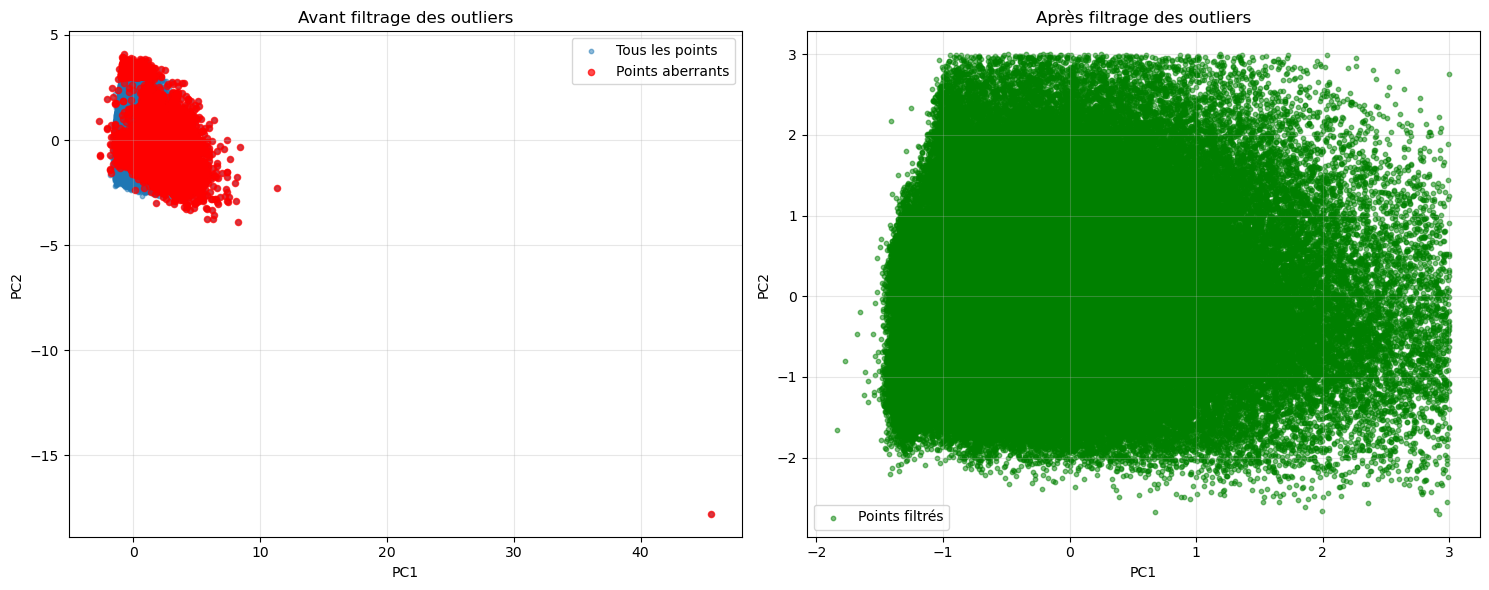

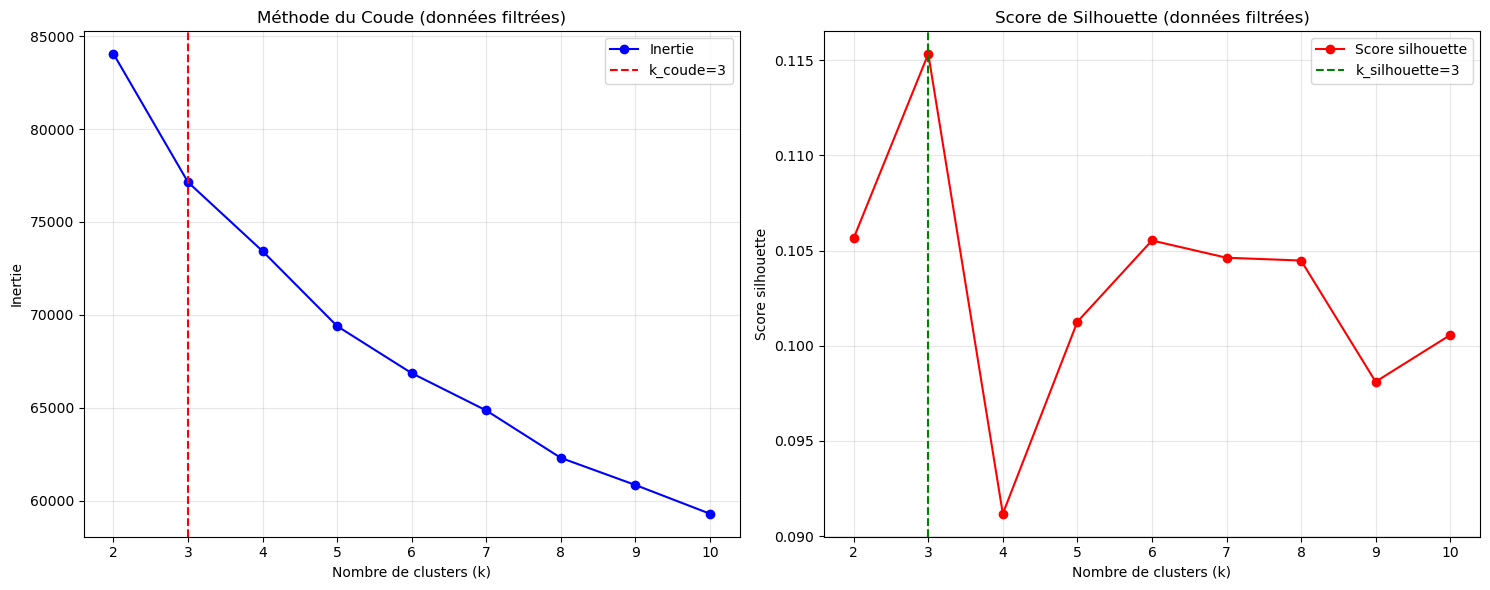

k silhouette optimal : 3
k coude (inertie) : 3

Application K-Means avec k_coude = 3
Distribution des clusters (incluant outliers=-1):
-1     5768
 0    38366
 1    74340
 2    54467
Name: count, dtype: int64


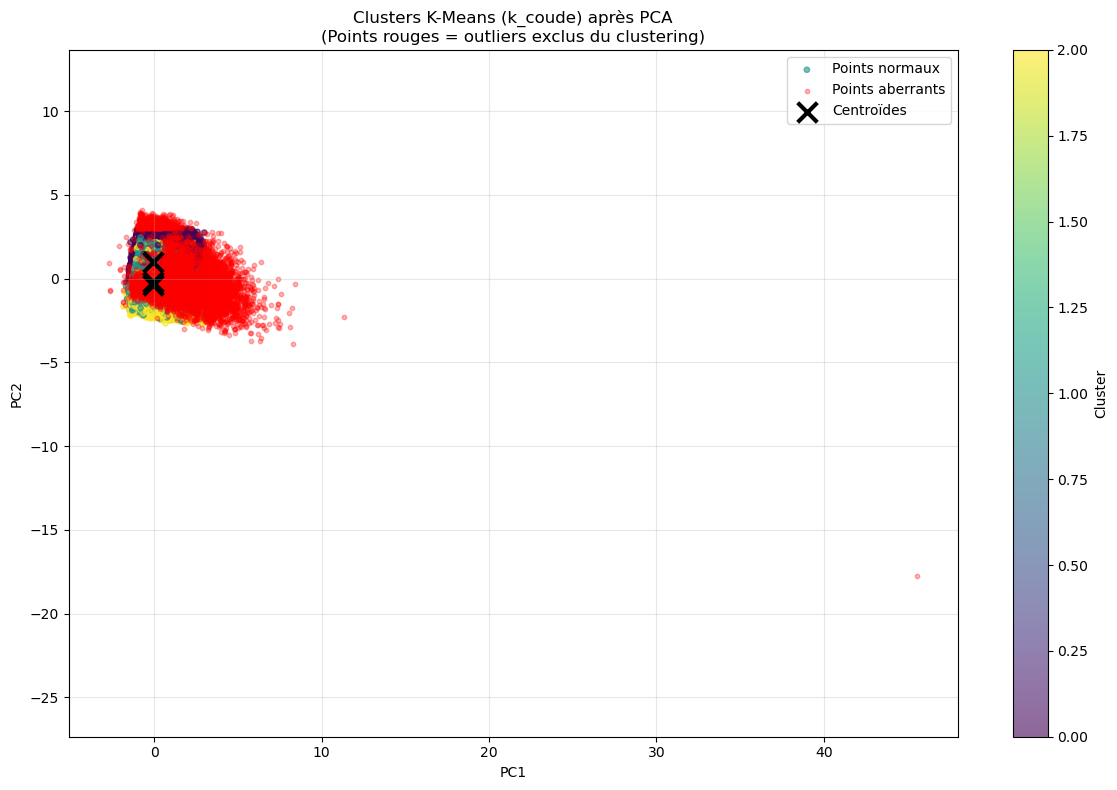

Points dans le clustering : 167173
Points exclus (outliers) : 5768
Score silhouette (données filtrées) : 0.115

Application K-Means avec k_silhouette = 3
Distribution des clusters (incluant outliers=-1):
-1     5768
 0    38366
 1    74340
 2    54467
Name: count, dtype: int64


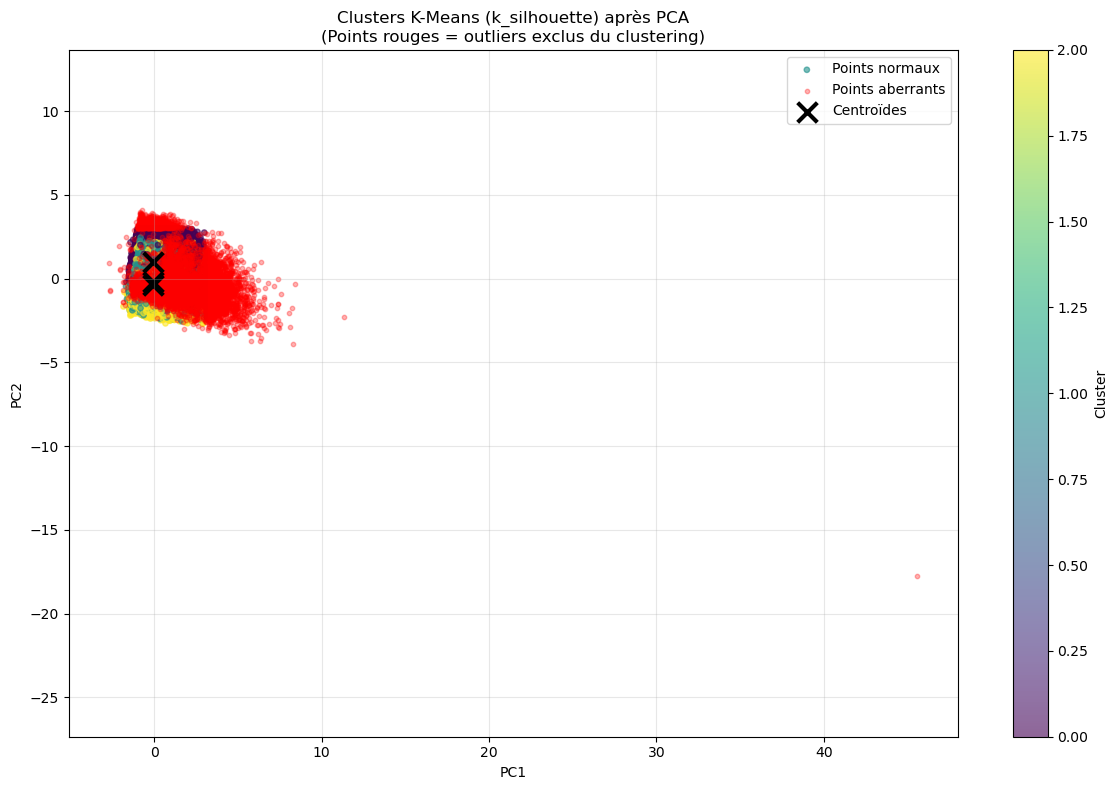

Points dans le clustering : 167173
Points exclus (outliers) : 5768
Score silhouette (données filtrées) : 0.115

Résultats sauvegardés dans : donnees_clusters_kmeans.csv

RÉSUMÉ FINAL
Données initiales : 172941 points
Données après filtrage : 167173 points
Points aberrants détectés : 5768
k optimal (silhouette) : 3
k optimal (coude) : 3


In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

# --------------------------
# 1. Charger les données après PCA
# --------------------------
df_pca = pd.read_csv("donnees_apres_pca.csv")

print("ÉTAPE : K-MEANS CLUSTERING APRÈS PCA")
print("-" * 50)

# --------------------------
# 2. Préparer les features PCA
# --------------------------
pca_features = [col for col in df_pca.columns if col.startswith('PC')]
X_pca = df_pca[pca_features].values

# Standardisation optionnelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# --------------------------
# 3. DÉTECTION ET FILTRAGE DES POINTS ABERRANTS
# --------------------------
def detecter_et_filtrer_outliers(X, z_threshold=3):
    """
    Détecte et filtre les points aberrants basés sur le score Z
    """
    # Calcul des scores Z pour chaque composante PCA
    z_scores = np.abs(stats.zscore(X, axis=0))
    
    # Identifier les points aberrants (au moins une composante > threshold)
    outliers_mask = np.any(z_scores > z_threshold, axis=1)
    
    print(f"Points détectés comme aberrants : {np.sum(outliers_mask)}")
    print(f"Pourcentage d'aberrants : {np.sum(outliers_mask) / len(X) * 100:.2f}%")
    
    # Filtrer les données
    X_filtered = X[~outliers_mask]
    indices_filtered = np.where(~outliers_mask)[0]
    
    return X_filtered, indices_filtered, outliers_mask

# Appliquer le filtrage des outliers
X_filtered, indices_filtered, outliers_mask = detecter_et_filtrer_outliers(X_scaled, z_threshold=3)

# Visualisation avant/après filtrage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Avant filtrage
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.5, s=10, label='Tous les points')
ax1.scatter(X_scaled[outliers_mask, 0], X_scaled[outliers_mask, 1], 
           c='red', alpha=0.7, s=20, label='Points aberrants')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Avant filtrage des outliers')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Après filtrage
ax2.scatter(X_filtered[:, 0], X_filtered[:, 1], alpha=0.5, s=10, c='green', label='Points filtrés')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Après filtrage des outliers')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------
# 4. Détermination des k (Coude + Silhouette) SUR DONNÉES FILTRÉES
# --------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores = []

# Échantillonnage pour accélérer le calcul
sample_size = min(10000, len(X_filtered))
sample_indices = np.random.choice(len(X_filtered), sample_size, replace=False)
X_sample = X_filtered[sample_indices]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, kmeans.labels_))

# k optimal selon silhouette
k_silhouette = k_range[np.argmax(silhouette_scores)]

# Méthode du coude améliorée - détection automatique
def find_elbow_point(inertias, k_range):
    """Trouve le point de coude automatiquement"""
    # Calcul des différences premières et secondes
    first_diff = np.diff(inertias)
    second_diff = np.diff(first_diff)
    
    # Le coude est où la seconde dérivée est maximale (changement de pente)
    elbow_index = np.argmax(np.abs(second_diff)) + 1  # +1 car on a pris des diff
    
    return k_range[elbow_index]

k_coude = find_elbow_point(inertias, list(k_range))

# Visualisation des critères
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(k_range, inertias, 'bo-', label='Inertie')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du Coude (données filtrées)')
ax1.axvline(x=k_coude, color='red', linestyle='--', label=f'k_coude={k_coude}')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', label='Score silhouette')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Score silhouette')
ax2.set_title('Score de Silhouette (données filtrées)')
ax2.axvline(x=k_silhouette, color='green', linestyle='--', label=f'k_silhouette={k_silhouette}')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"k silhouette optimal : {k_silhouette}")
print(f"k coude (inertie) : {k_coude}")

# --------------------------
# 5. Application K-Means pour les deux k SUR DONNÉES FILTRÉES
# --------------------------
for k, label in zip([k_coude, k_silhouette], ['k_coude', 'k_silhouette']):
    print(f"\nApplication K-Means avec {label} = {k}")
    
    # K-Means sur données filtrées
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    clusters_filtered = kmeans.fit_predict(X_filtered)
    
    # Assigner les clusters aux données originales (outliers = -1)
    clusters_full = np.full(len(X_scaled), -1)  # -1 pour outliers
    clusters_full[indices_filtered] = clusters_filtered
    
    df_pca[f'cluster_{label}'] = clusters_full
    
    print("Distribution des clusters (incluant outliers=-1):")
    cluster_counts = pd.Series(clusters_full).value_counts().sort_index()
    print(cluster_counts)
    
    # Visualisation avec gestion des échelles automatique
    plt.figure(figsize=(12, 8))
    
    # Points normaux
    normal_points = clusters_full != -1
    scatter_normal = plt.scatter(X_scaled[normal_points, 0], X_scaled[normal_points, 1], 
                                c=clusters_full[normal_points], cmap='viridis', 
                                alpha=0.6, s=15, label='Points normaux')
    
    # Points aberrants (cluster -1)
    outlier_points = clusters_full == -1
    if np.sum(outlier_points) > 0:
        plt.scatter(X_scaled[outlier_points, 0], X_scaled[outlier_points, 1], 
                   c='red', alpha=0.3, s=10, label='Points aberrants')
    
    # Centroïdes
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='black', marker='x', s=200, linewidths=3, label='Centroïdes')
    
    # Détermination automatique des limites pour zoomer sur la majorité des données
    if np.sum(normal_points) > 0:
        x_normal = X_scaled[normal_points, 0]
        y_normal = X_scaled[normal_points, 1]
        
        # Utiliser les percentiles pour éviter l'influence des outliers restants
        x_lower = np.percentile(x_normal, 1)
        x_upper = np.percentile(x_normal, 99)
        y_lower = np.percentile(y_normal, 1)
        y_upper = np.percentile(y_normal, 99)
        
        # Ajouter une marge
        x_margin = (x_upper - x_lower) * 0.1
        y_margin = (y_upper - y_lower) * 0.1
        
        plt.xlim(x_lower - x_margin, x_upper + x_margin)
        plt.ylim(y_lower - y_margin, y_upper + y_margin)
    
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Clusters K-Means ({label}) après PCA\n(Points rouges = outliers exclus du clustering)')
    plt.axis("equal")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.colorbar(scatter_normal, label='Cluster')
    plt.tight_layout()
    plt.show()
    
    # Statistiques supplémentaires
    print(f"Points dans le clustering : {np.sum(normal_points)}")
    print(f"Points exclus (outliers) : {np.sum(outlier_points)}")
    print(f"Score silhouette (données filtrées) : {silhouette_score(X_filtered, clusters_filtered):.3f}")

# --------------------------
# 6. SAUVEGARDE DES RÉSULTATS
# --------------------------
# Ajouter une colonne indiquant les outliers
df_pca['is_outlier'] = outliers_mask

# Sauvegarder les résultats
output_filename = "donnees_clusters_kmeans.csv"
df_pca.to_csv(output_filename, index=False)
print(f"\nRésultats sauvegardés dans : {output_filename}")

# Résumé final
print("\n" + "="*50)
print("RÉSUMÉ FINAL")
print("="*50)
print(f"Données initiales : {len(X_scaled)} points")
print(f"Données après filtrage : {len(X_filtered)} points")
print(f"Points aberrants détectés : {np.sum(outliers_mask)}")
print(f"k optimal (silhouette) : {k_silhouette}")
print(f"k optimal (coude) : {k_coude}")

In [183]:
import joblib

# Après avoir entraîné ton modèle K-Means
kmeans = KMeans(n_clusters=k_silhouette, random_state=42, n_init=10, max_iter=300)
clusters = kmeans.fit_predict(X_scaled)

# Sauvegarde du modèle
joblib.dump(kmeans, "modele_kmeans.pkl")

print("✅ Modèle K-Means sauvegardé dans 'modele_kmeans.pkl'")


✅ Modèle K-Means sauvegardé dans 'modele_kmeans.pkl'
